# Capstone Coding Camp: DiaWellness
Member:

- Mohammad Valeriant Qumara Tanda (MC180D5Y0566) - Machine Learning - Universitas Airlangga
- Farhan Al Fauzan (MC180D5Y1028) - Machine Learning - Universitas Airlangga
- Laila (MC180D5X0508) - Machine Learning - Universitas Airlangga
- Asrafatin Nabillah (FC180D5X1575) - Frontend/Backend - Universitas Airlangga
- Sabillah Nur Fitriyanah (FC180D5X1576) - Frontend/Backend - Universitas Airlangga
- Fatimah Ash Syahidah (FC816D5X0968) - Frontend/Backend - Institut Teknologi Insan Cendekia Mandiri


## Import Library and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from imblearn.over_sampling import SMOTE
import optuna
import time
from optuna.integration import KerasPruningCallback

2025-06-10 09:27:17.601365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 09:27:17.618930: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-10 09:27:17.735719: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-10 09:27:17.819918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749522437.901943    1577 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749522437.93

In [2]:
# Read Dataset
df = pd.read_csv('/home/valenttanda/capstone/data/diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


## EDA

In [3]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


No Missing Values Detected

In [4]:
# Dataset Statistics
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
# Checking Duplicated Data
print("Duplicated Data: ", df.duplicated().sum())

Duplicated Data:  3854


In [6]:
# Drop Duplicated Data
df.drop_duplicates(inplace=True)
print("Duplicated Data After drop_duplcates: ", df.duplicated().sum())
print(f"New Dataset Shape: {df.shape}")

Duplicated Data After drop_duplcates:  0
New Dataset Shape: (96146, 9)


In [7]:
# Checking New Dataset Statistics
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


### Data Visualization

#### Histogram Plot

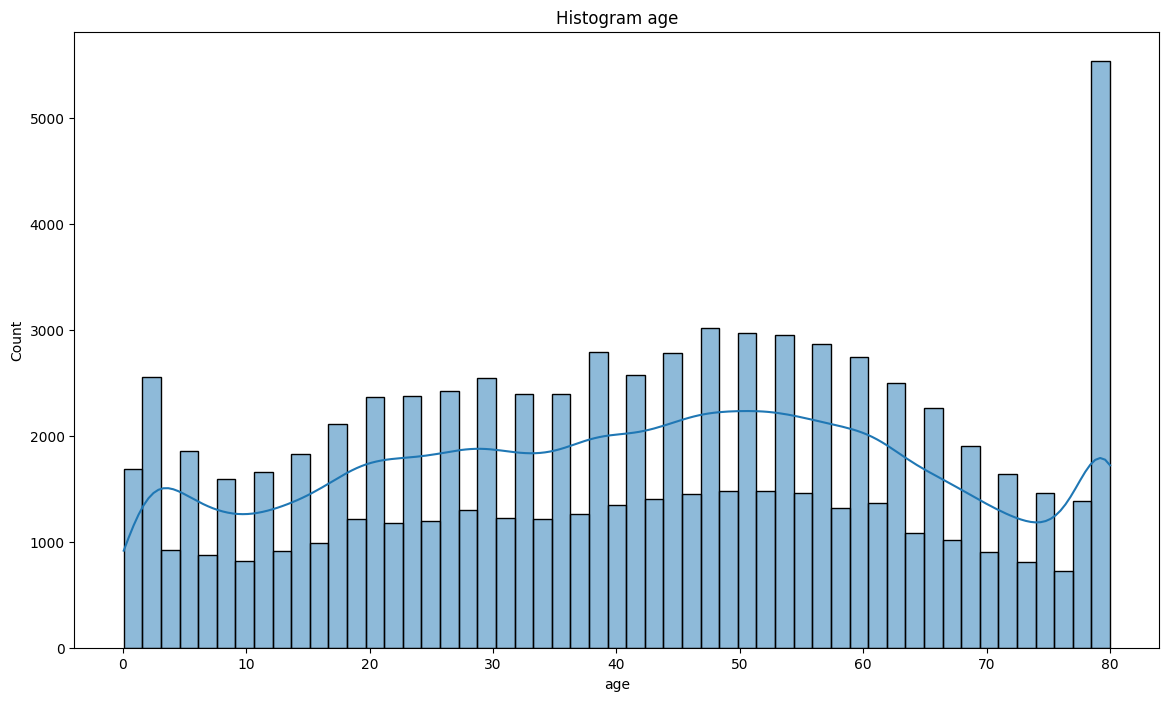

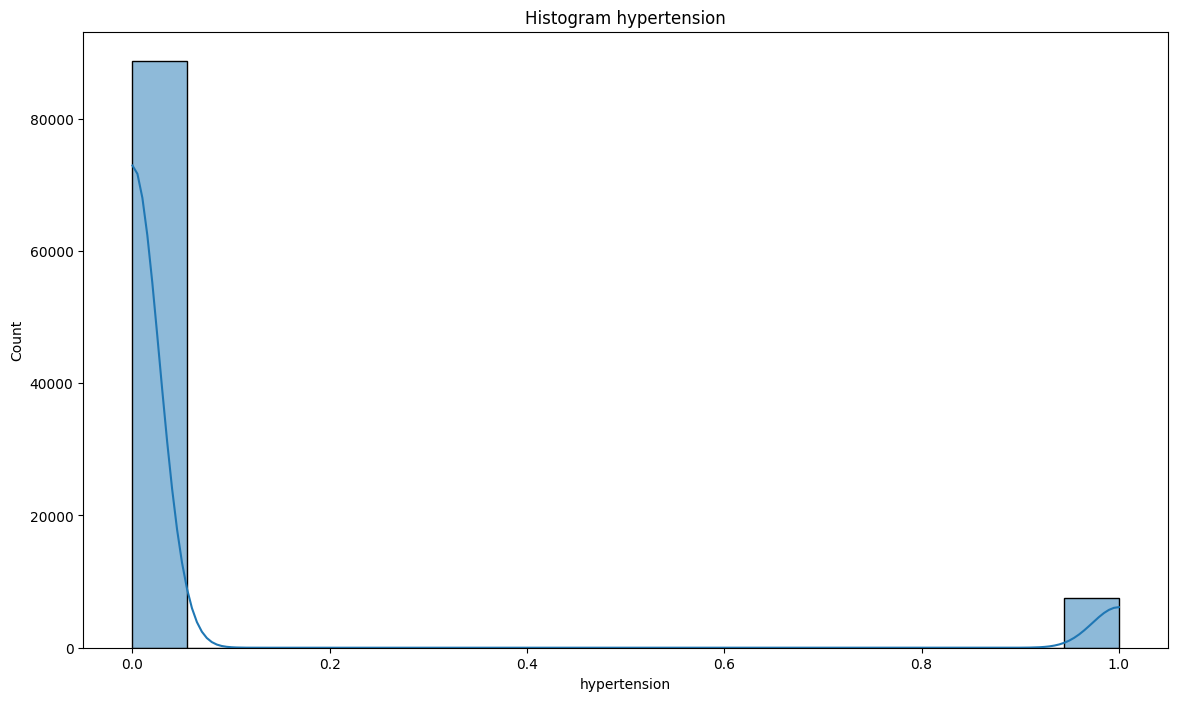

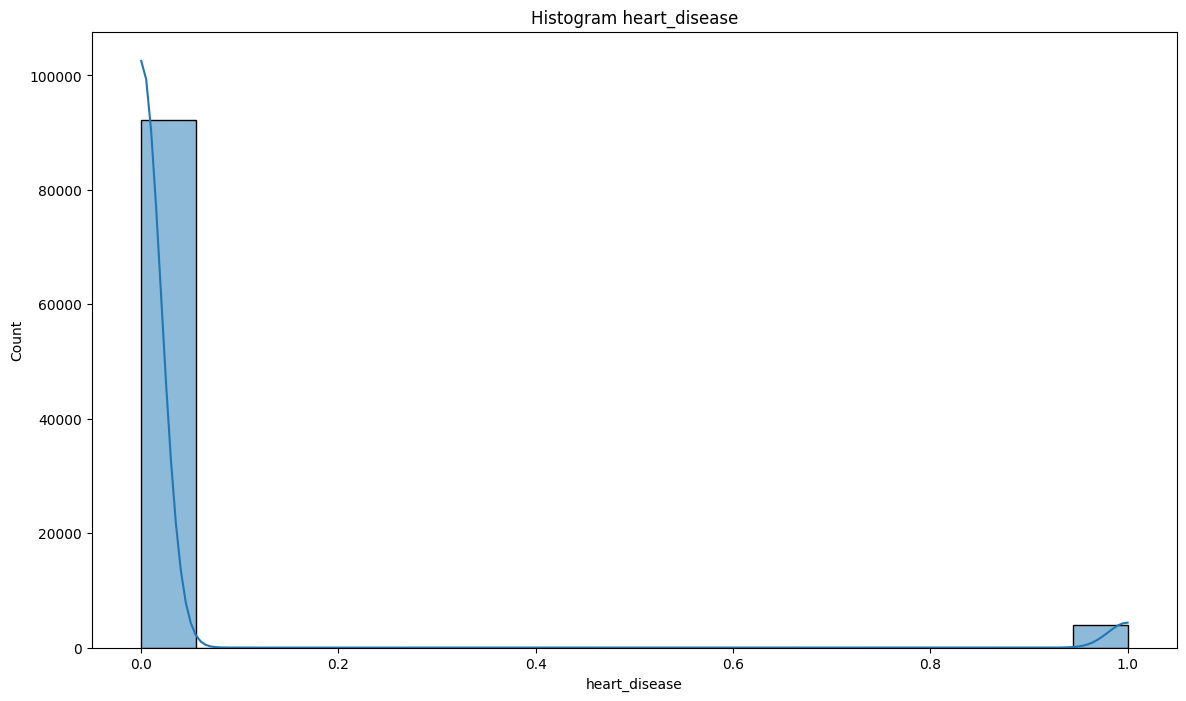

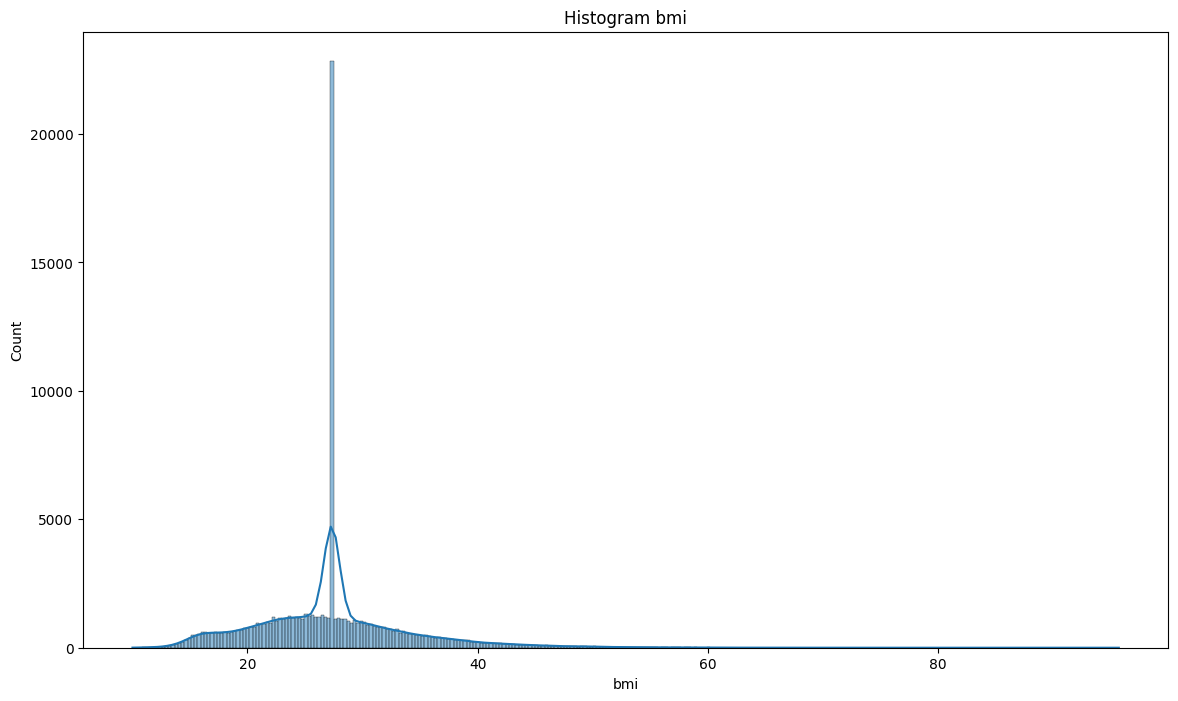

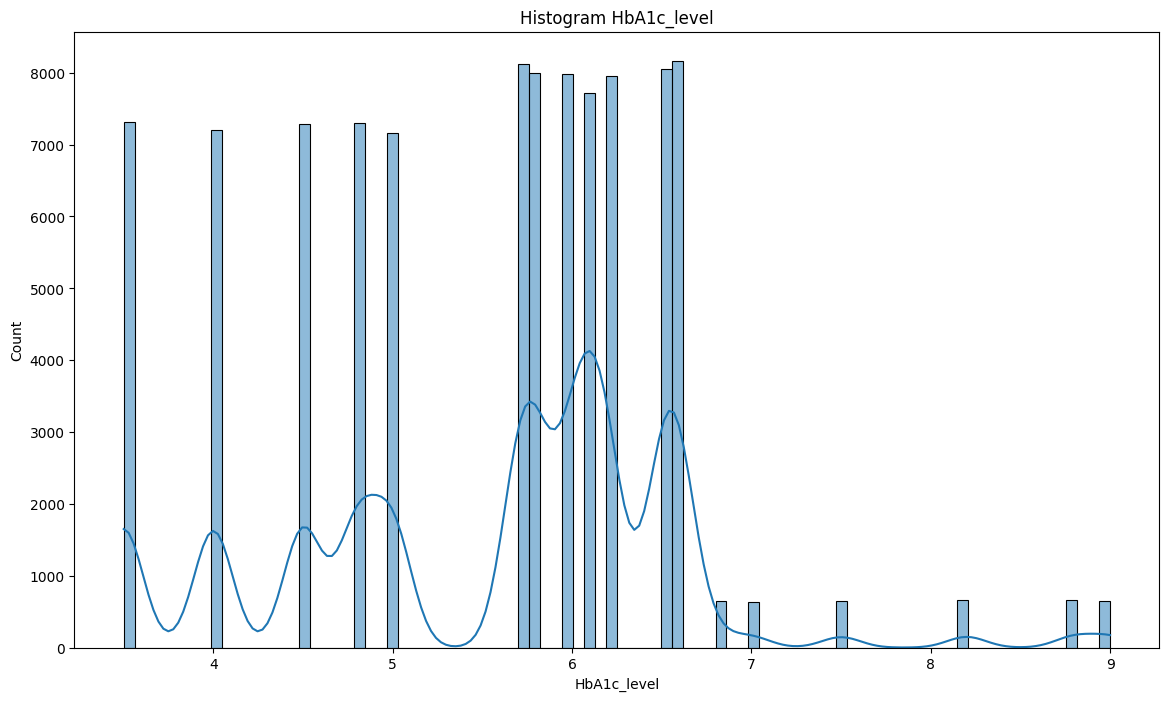

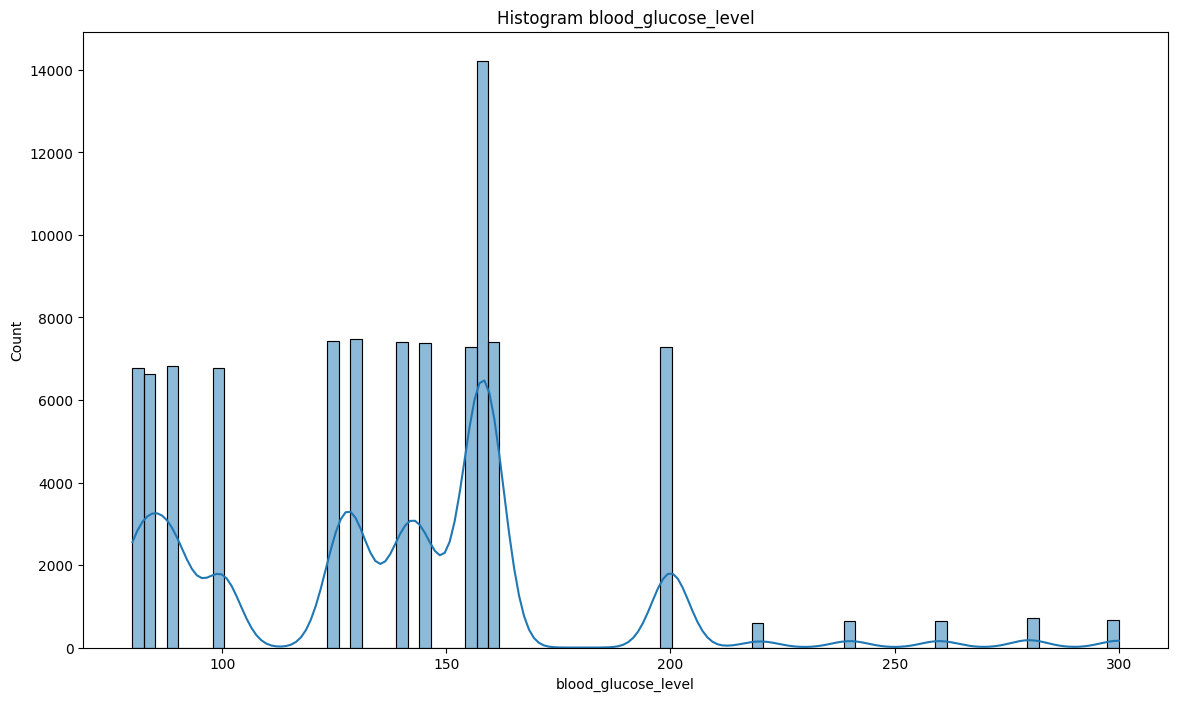

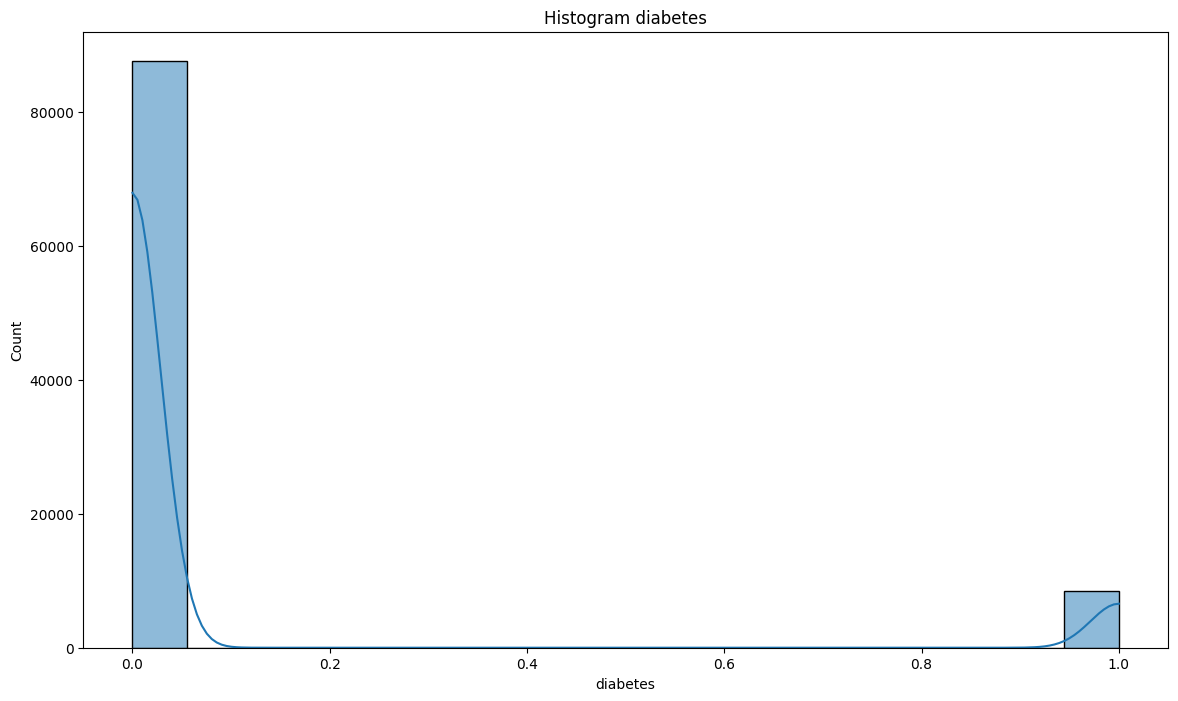

In [8]:
numerical = df.select_dtypes(include=np.number)
for column in numerical:
  plt.figure(figsize=(14,8))
  sns.histplot(data=df, x=column, kde=True)
  plt.title(f"Histogram {column}")
  plt.show()

Check Skewness Data

In [9]:
"""
If skewness < 0: left-skewed
If skewness > 0: right-skewed
If skewness = 0: normal
"""
from scipy.stats import skew
for column in numerical.columns:
  if (df[column].dtype == 'object') or (df[column].nunique() == 2):
    continue
  print(f"Skewness {column}: {skew(df[column]).round(3)}")

Skewness age: -0.062
Skewness bmi: 1.024
Skewness HbA1c_level: -0.054
Skewness blood_glucose_level: 0.836


Do Log Transformation to bmi and blood_glucose_level Columns

#### Heatmap

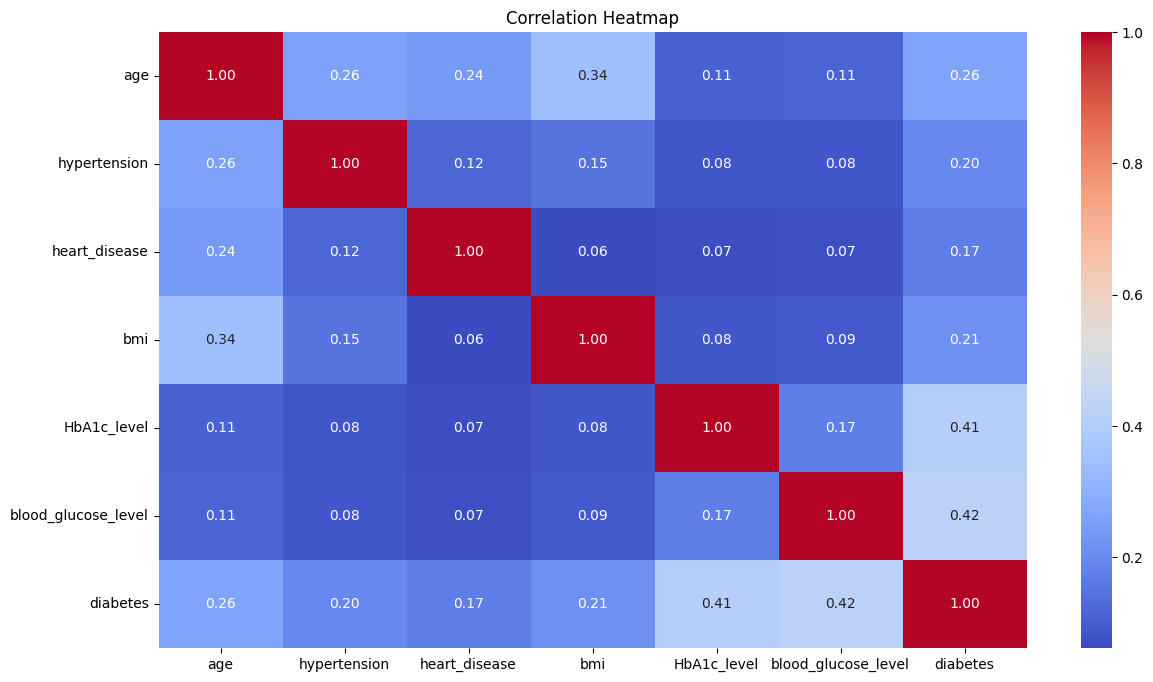

In [10]:
plt.figure(figsize=(14,8))
sns.heatmap(numerical.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Drop hypertension dan heart_disease Columns

#### Boxplot

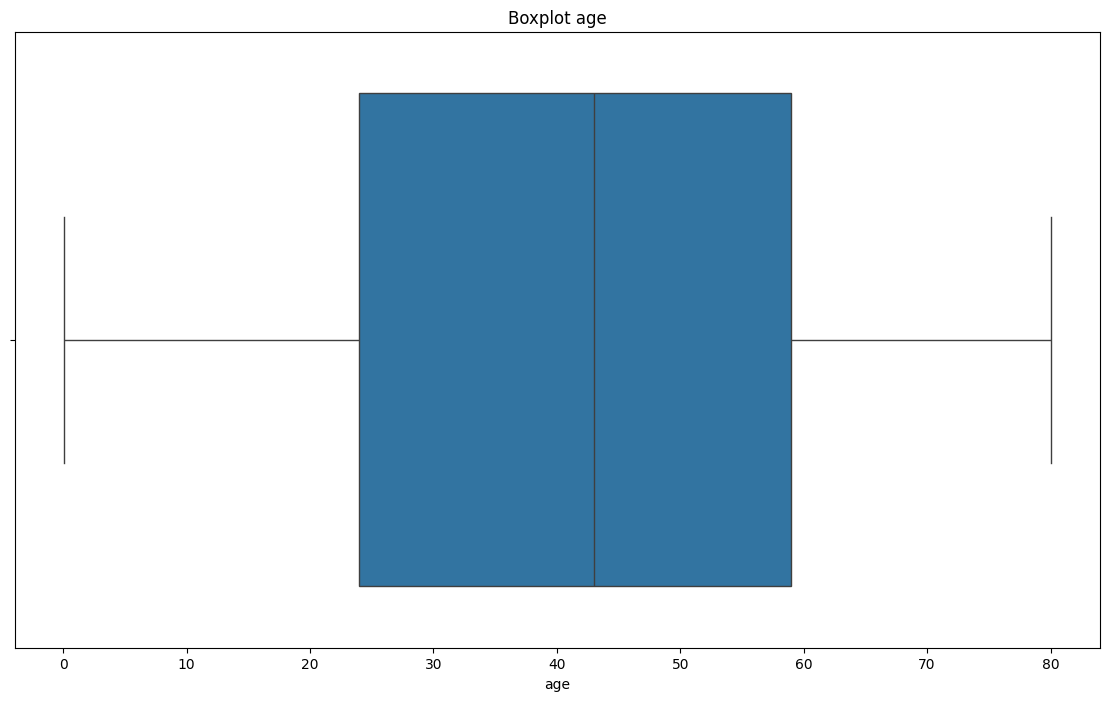

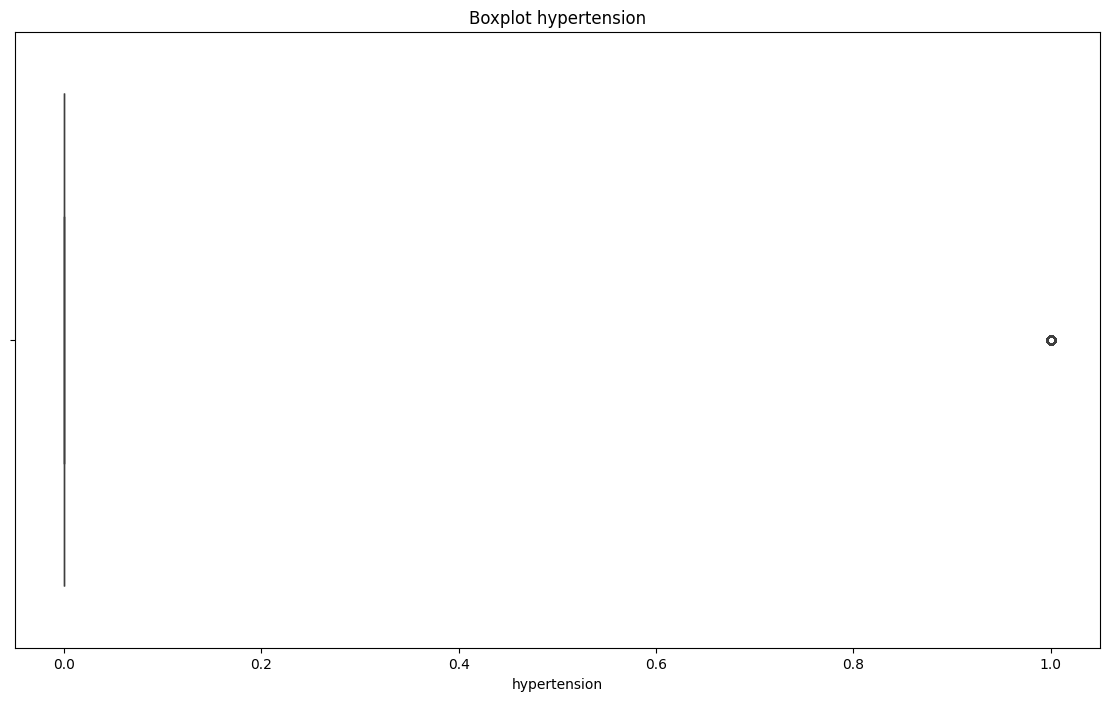

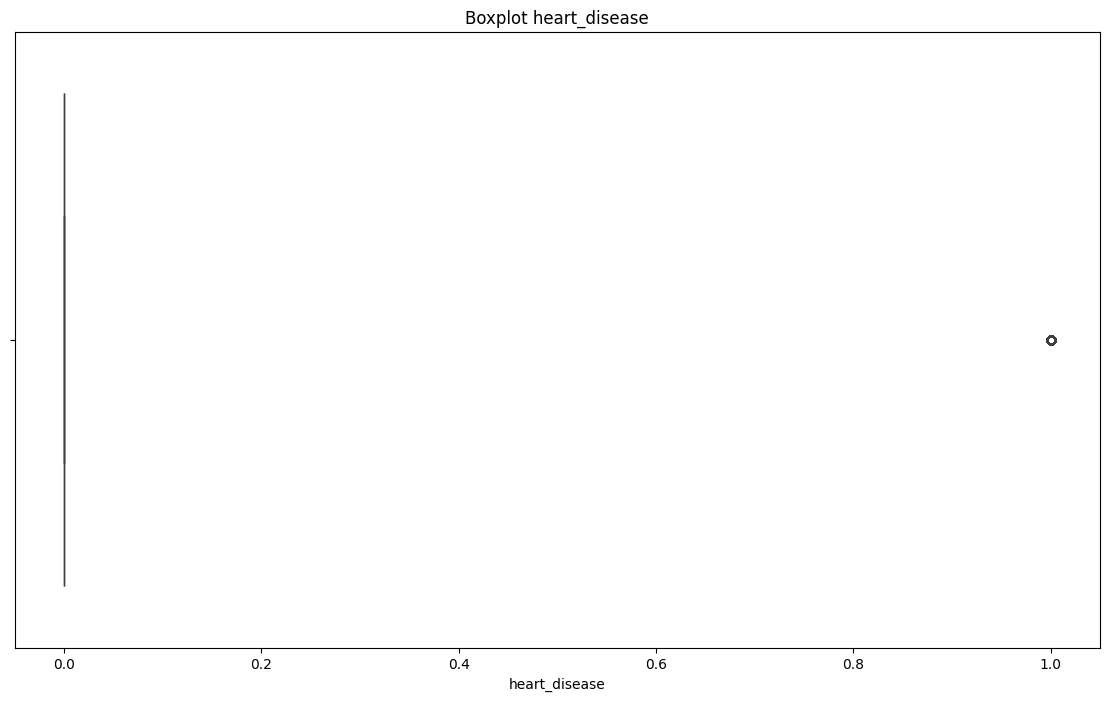

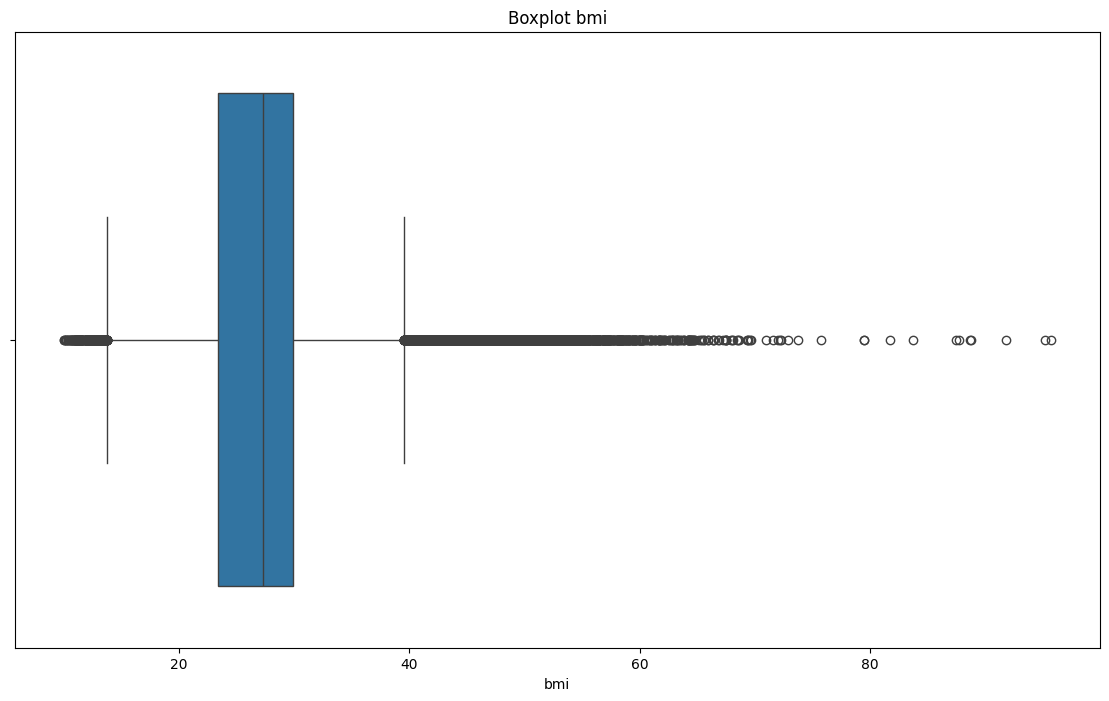

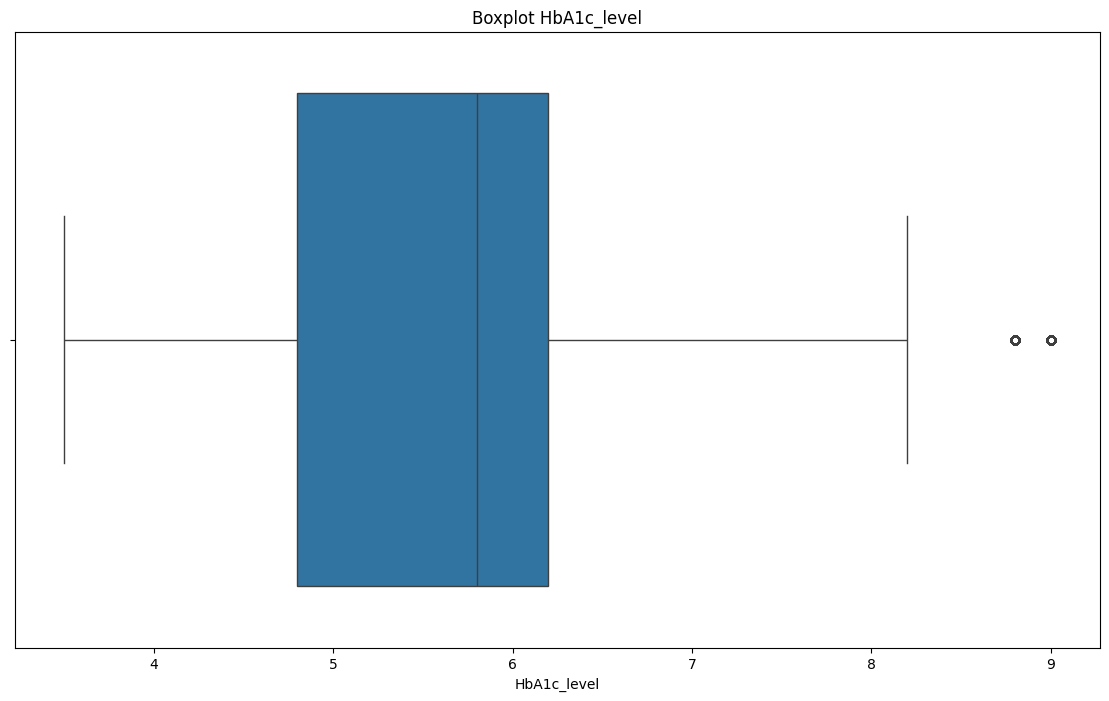

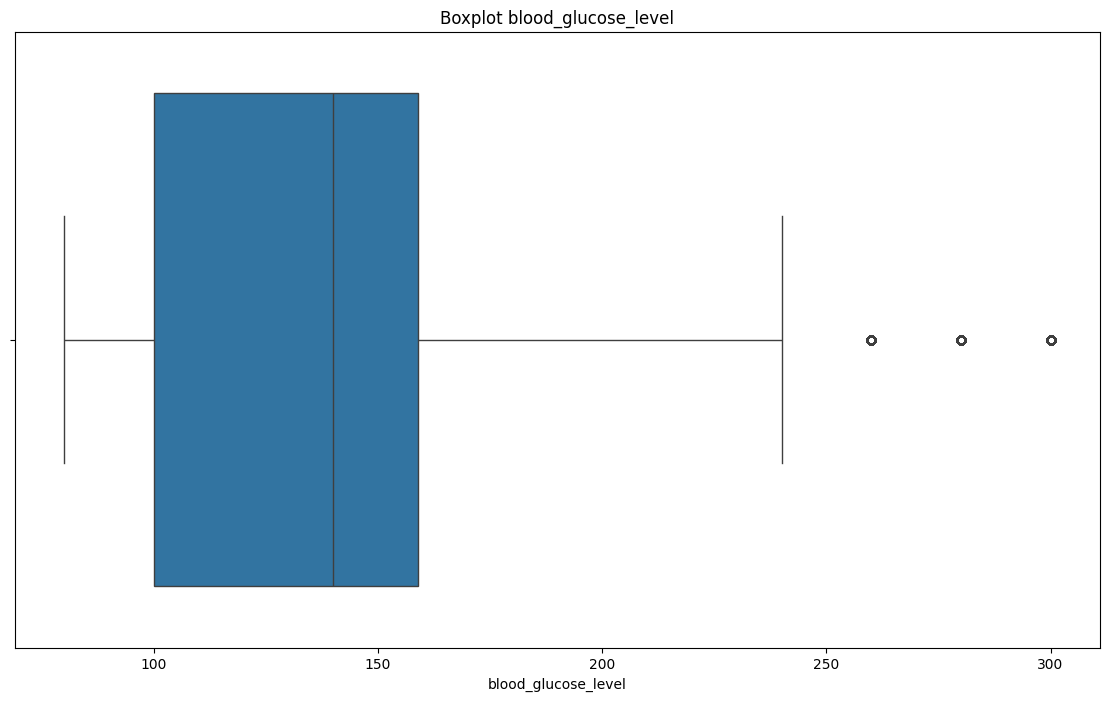

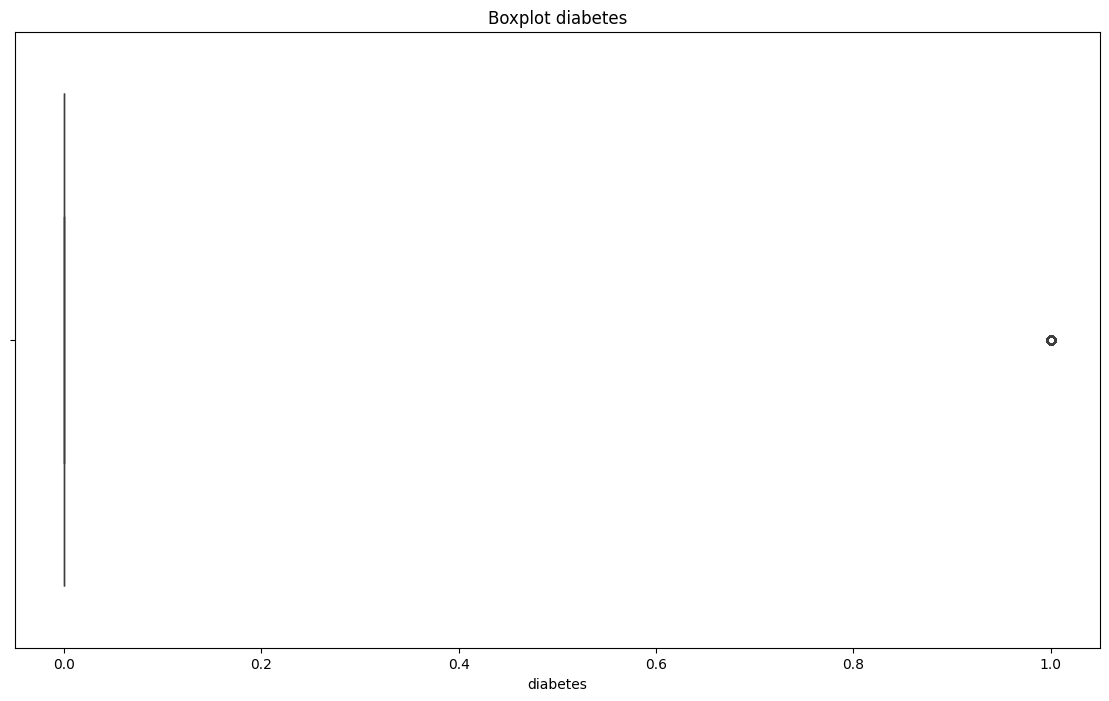

In [11]:
for column in numerical.columns:
  plt.figure(figsize=(14,8))
  sns.boxplot(data=df, x=column)
  plt.title(f"Boxplot {column}")
  plt.show()

Handling Outlier to bmi and blood_glucose_level Columns

#### Pairplot

<Figure size 1400x800 with 0 Axes>

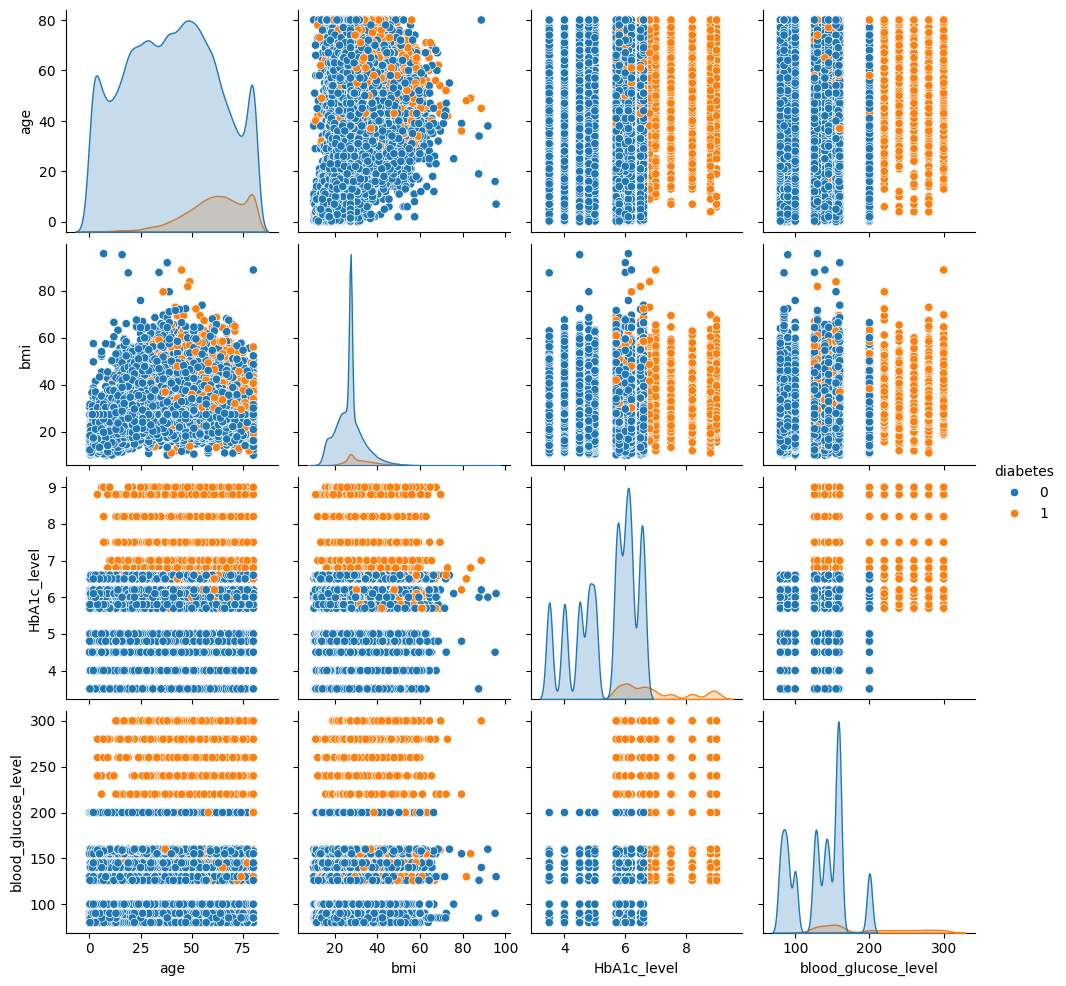

In [12]:
plot_column = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
plt.figure(figsize=(14,8))
sns.pairplot(df[plot_column], hue='diabetes', diag_kind='kde')
plt.show()

Label Distribution

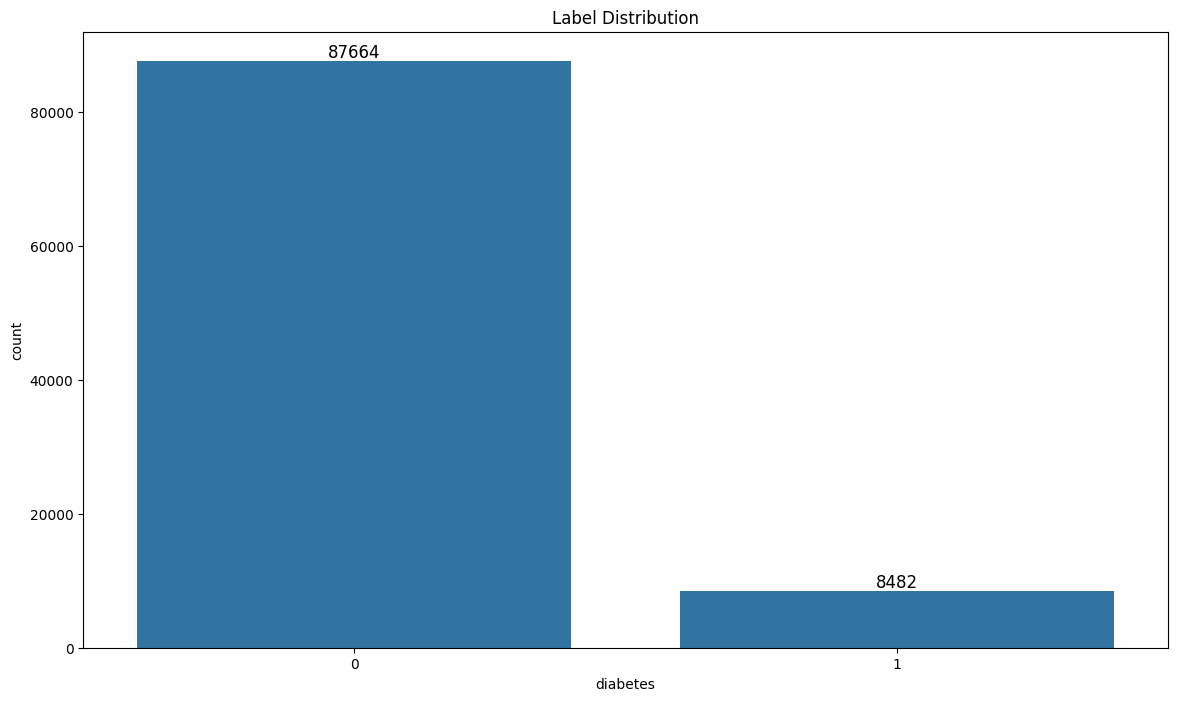

In [13]:
plt.figure(figsize=(14, 8))
ax = sns.countplot(data=df, x='diabetes')
plt.title("Label Distribution")

# Tambahkan angka di atas setiap batang
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

## Preprocessing Data

### Data Preparation

In [14]:
df_preprocessed = df.copy()

In [15]:
# Split Numerical and Categorical Features
numerical_columns = df_preprocessed.select_dtypes(include=np.number)
categorical_columns = df_preprocessed.select_dtypes(include='object')

# Prepare Columns for Preprocessing Based on Data Visualization
num_log_col = df_preprocessed[['bmi', 'blood_glucose_level']]
num_drop_col = df_preprocessed[['hypertension', 'heart_disease']]
num_other_col = df_preprocessed[['age', 'HbA1c_level']]
cat_col = df_preprocessed[['gender', 'smoking_history']]

In [16]:
# Drop Unnecessary Columns
df_preprocessed.drop(columns=['hypertension', 'heart_disease'], inplace=True)
df_preprocessed

,gender,age,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,never,25.19,6.6,140,0
1,Female,54.0,No Info,27.32,6.6,80,0
2,Male,28.0,never,27.32,5.7,158,0
3,Female,36.0,current,23.45,5.0,155,0
4,Male,76.0,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...
99994,Female,36.0,No Info,24.60,4.8,145,0
99996,Female,2.0,No Info,17.37,6.5,100,0
99997,Male,66.0,former,27.83,5.7,155,0
99998,Female,24.0,never,35.42,4.0,100,0


### Preprocessing

#### 1. Handling Outlier

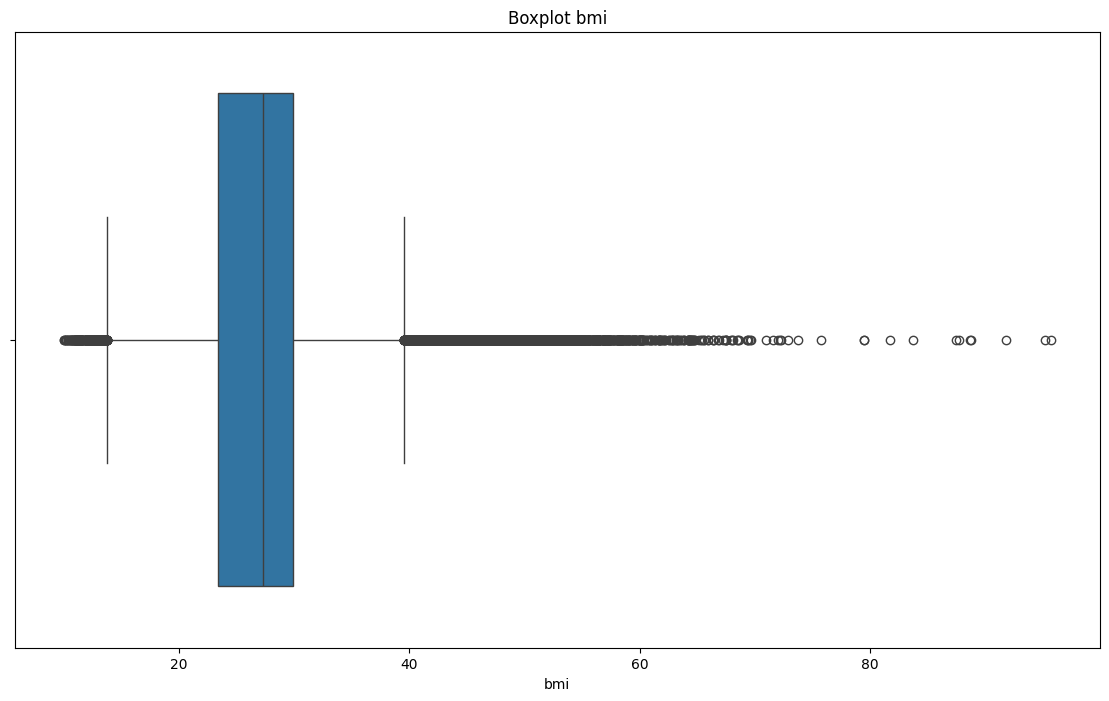

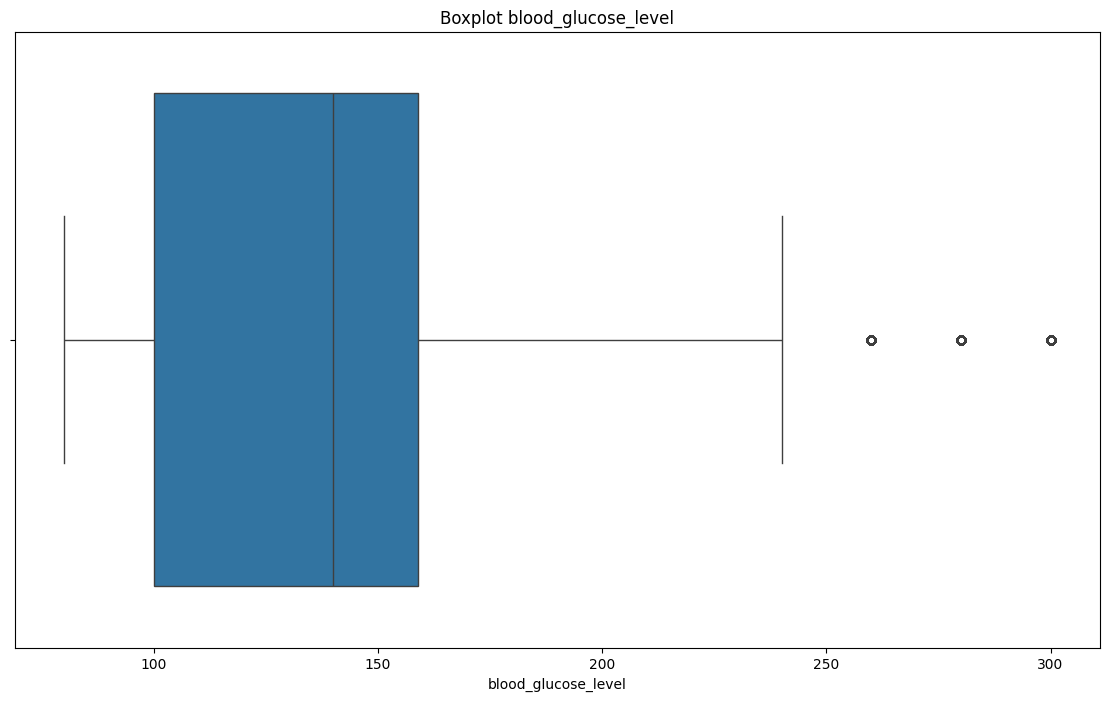

Data Shape Before Outlier Cleaning: (96146, 7)


In [17]:
# Outlier Check for num_log_col
for column in num_log_col:
  # Count Outliers
  q1 = num_log_col[column].quantile(0.25)
  q3 = num_log_col[column].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = num_log_col[(num_log_col[column] < lower_bound) | (num_log_col[column] > upper_bound)]

  # Boxplot
  plt.figure(figsize=(14,8))
  sns.boxplot(data=df_preprocessed, x=column)
  plt.title(f"Boxplot {column}")
  plt.show()

# Data Shape Before Outlier Cleaning
print(f"Data Shape Before Outlier Cleaning: {df_preprocessed.shape}")

Drop Outliers

In [18]:
# Seperate Data for Different Outlier Removal Techniques
df_preprocessed_outlier_iqr = df_preprocessed.copy()
df_preprocessed_outlier_z = df_preprocessed.copy()

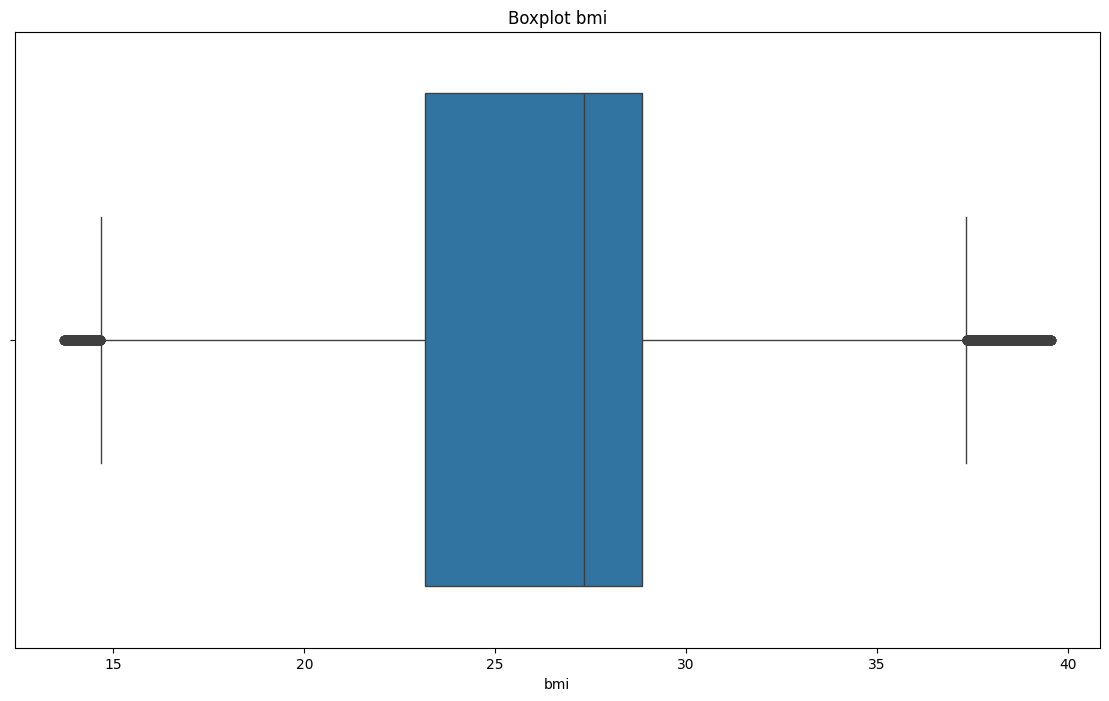

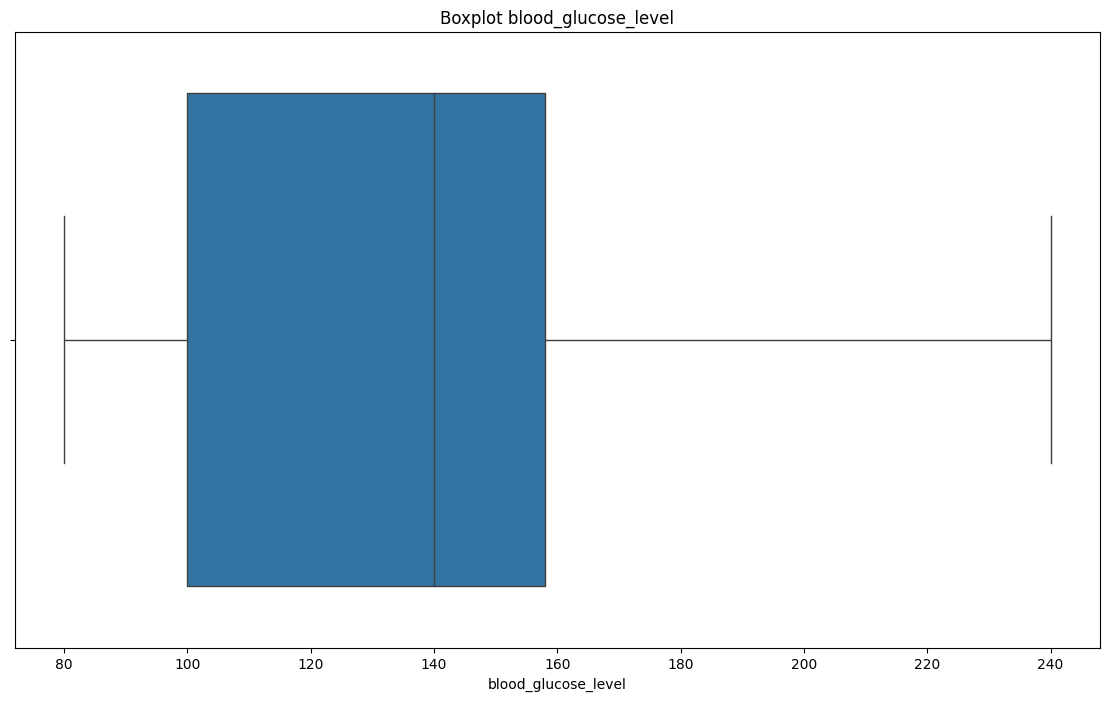

Data Shape After Outlier Cleaning: (89072, 7)


In [19]:
# 1. IQR Method
for column in num_log_col.columns:
  q1 = df_preprocessed_outlier_iqr[column].quantile(0.25)
  q3 = df_preprocessed_outlier_iqr[column].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  df_preprocessed_outlier_iqr = df_preprocessed_outlier_iqr[(df_preprocessed_outlier_iqr[column] >= lower_bound) & (df_preprocessed_outlier_iqr[column] <= upper_bound)]

  # Boxplot
  plt.figure(figsize=(14,8))
  sns.boxplot(data=df_preprocessed_outlier_iqr, x=column)
  plt.title(f"Boxplot {column}")
  plt.show()

# Data Shape After Outlier Cleaning
print(f"Data Shape After Outlier Cleaning: {df_preprocessed_outlier_iqr.shape}")

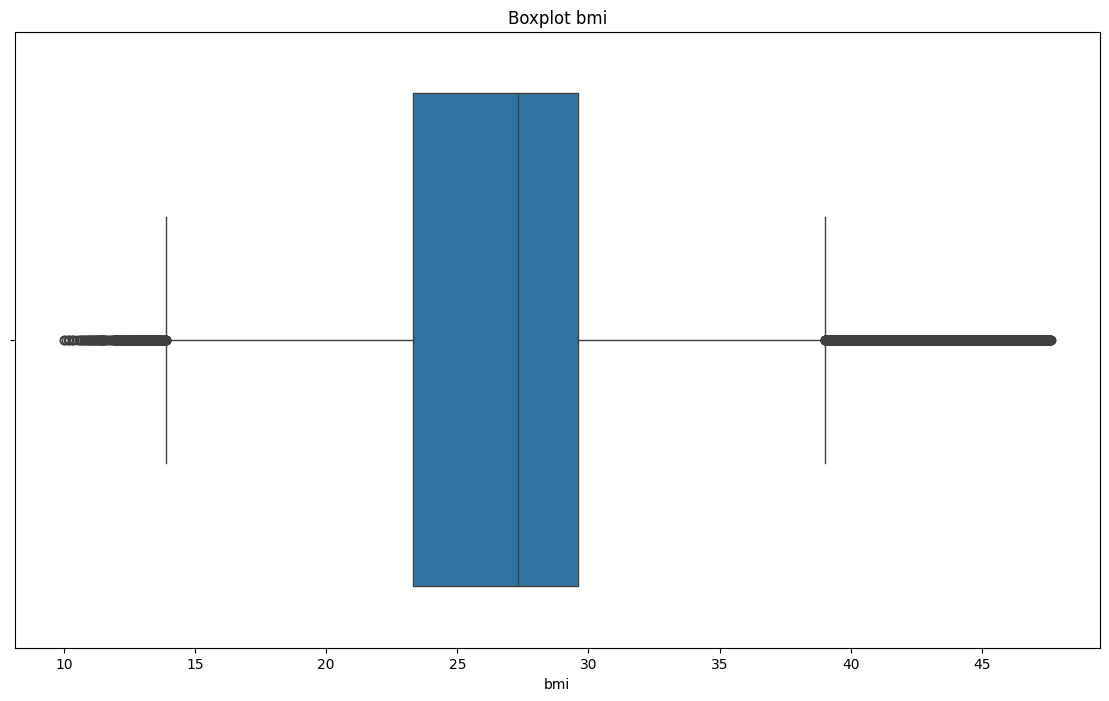

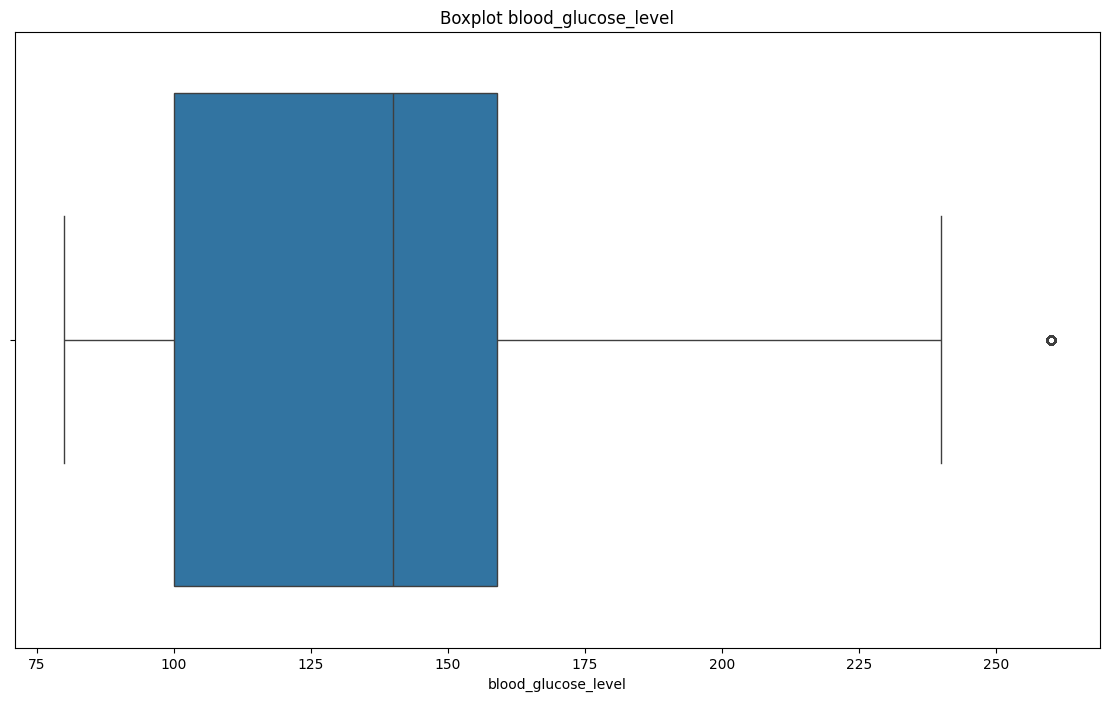

Data Shape After Outlier Cleaning: (93597, 7)


In [20]:
# 2. Z-score Method
for column in num_log_col.columns:
  # Check Outliers
  mean = df_preprocessed_outlier_z[column].mean()
  std = df_preprocessed_outlier_z[column].std()
  df_preprocessed_outlier_z = df_preprocessed_outlier_z[(np.abs(df_preprocessed_outlier_z[column] - mean) / std) <= 3]

  # Boxplot
  plt.figure(figsize=(14,8))
  sns.boxplot(data=df_preprocessed_outlier_z, x=column)
  plt.title(f"Boxplot {column}")
  plt.show()

# Data Shape After Outlier Cleaning
print(f"Data Shape After Outlier Cleaning: {df_preprocessed_outlier_z.shape}")

In [21]:
# Data Shape Comparison
outlier_handling = pd.DataFrame({
    'Outlier Handling Method': ['IQR', 'Z-score'],
    'Data Shape Before Outlier Cleaning': [df_preprocessed.shape, df_preprocessed.shape],
    'Data Shape After Outlier Cleaning': [df_preprocessed_outlier_iqr.shape, df_preprocessed_outlier_z.shape]
})
outlier_handling

,Outlier Handling Method,Data Shape Before Outlier Cleaning,Data Shape After Outlier Cleaning
0,IQR,"(96146, 7)","(89072, 7)"
1,Z-score,"(96146, 7)","(93597, 7)"


Conclusion: Use Z-score method for outlier cleaning as it every data was reasonable, so more data with outlier will be more realistic

#### 2. Log Transformation (blood_glucose_level)

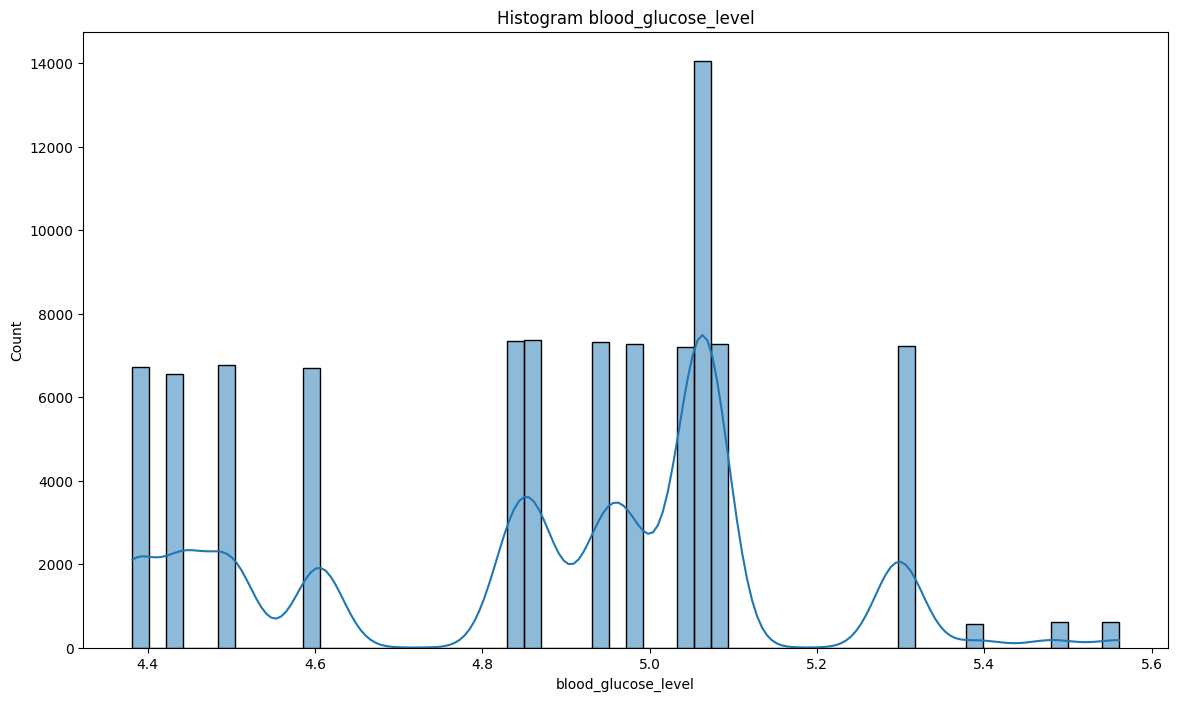

In [22]:
# Do Log Transformation using df_preprocessed_outlier_z dataset
df_preprocessed_transformed = df_preprocessed_outlier_z.copy()
df_preprocessed_transformed['blood_glucose_level'] = np.log(df_preprocessed_transformed['blood_glucose_level'])
plt.figure(figsize=(14,8))
sns.histplot(data=df_preprocessed_transformed, x='blood_glucose_level', kde=True)
plt.title(f"Histogram {'blood_glucose_level'}")
plt.show()

In [23]:
print(f"Data statistics before transformation: \n{df_preprocessed_outlier_z.describe()}")
print(f"Data statistics after transformation: \n{df_preprocessed_transformed.describe()}")

Data statistics before transformation: 
                age          bmi   HbA1c_level  blood_glucose_level  \
count  93597.000000  93597.00000  93597.000000         93597.000000   
mean      41.477080     26.93148      5.509043           135.917957   
std       22.521208      6.08952      1.057317            36.761527   
min        0.080000     10.01000      3.500000            80.000000   
25%       23.000000     23.26000      4.800000           100.000000   
50%       42.000000     27.32000      5.800000           140.000000   
75%       59.000000     29.49000      6.200000           159.000000   
max       80.000000     47.62000      9.000000           260.000000   

           diabetes  
count  93597.000000  
mean       0.072641  
std        0.259548  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  
Data statistics after transformation: 
                age          bmi   HbA1c_level  blood_glucose_level  \
count  93597

#### 3. Binning (smoking_history)

In [24]:
# Get smoking_history data
df_preprocessed_binned = df_preprocessed_transformed.copy()
df_preprocessed_binned['smoking_history'].value_counts()

smoking_history
never          33388
No Info        32390
current         8900
former          8884
not current     6160
ever            3875
Name: count, dtype: int64

In [25]:
# Binning Process
df_preprocessed_binned['smoking_history'] = df_preprocessed_binned['smoking_history'].replace({
    'never': 'No',
    'No Info': 'Unknown',
    'current': 'Yes',
    'former': 'Yes',
    'not current': 'Yes',
    'ever': 'Yes'
})
df_preprocessed_binned['smoking_history'].value_counts()

smoking_history
No         33388
Unknown    32390
Yes        27819
Name: count, dtype: int64

In [26]:
df_preprocessed_binned

,gender,age,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,No,25.19,6.6,4.941642,0
1,Female,54.0,Unknown,27.32,6.6,4.382027,0
2,Male,28.0,No,27.32,5.7,5.062595,0
3,Female,36.0,Yes,23.45,5.0,5.043425,0
4,Male,76.0,Yes,20.14,4.8,5.043425,0
...,...,...,...,...,...,...,...
99994,Female,36.0,Unknown,24.60,4.8,4.976734,0
99996,Female,2.0,Unknown,17.37,6.5,4.605170,0
99997,Male,66.0,Yes,27.83,5.7,5.043425,0
99998,Female,24.0,No,35.42,4.0,4.605170,0


#### 4. Binning (bmi)

In [27]:
print(f"Minimum data from bmi: \n{df_preprocessed_binned['bmi'].min()}")
print(f"Maximum data from bmi: \n{df_preprocessed_binned['bmi'].max()}\n")
print(f"bmi data statistics before binning: \n{df_preprocessed_binned['bmi'].describe()}\n")
print(f"bmi data values: \n{df_preprocessed_binned['bmi'].value_counts()}")

Minimum data from bmi: 
10.01
Maximum data from bmi: 
47.62

bmi data statistics before binning: 
count    93597.00000
mean        26.93148
std          6.08952
min         10.01000
25%         23.26000
50%         27.32000
75%         29.49000
max         47.62000
Name: bmi, dtype: float64

bmi data values: 
bmi
27.32    21441
23.00      102
27.12      101
24.96      100
22.40       99
         ...  
42.85        1
13.10        1
46.62        1
13.13        1
43.44        1
Name: count, Length: 3519, dtype: int64


bmi data values after binning: 
bmi
Obese Class I     41021
Obese Class II    21642
Normal            13415
Underweight        8480
Overweight         7831
Name: count, dtype: int64



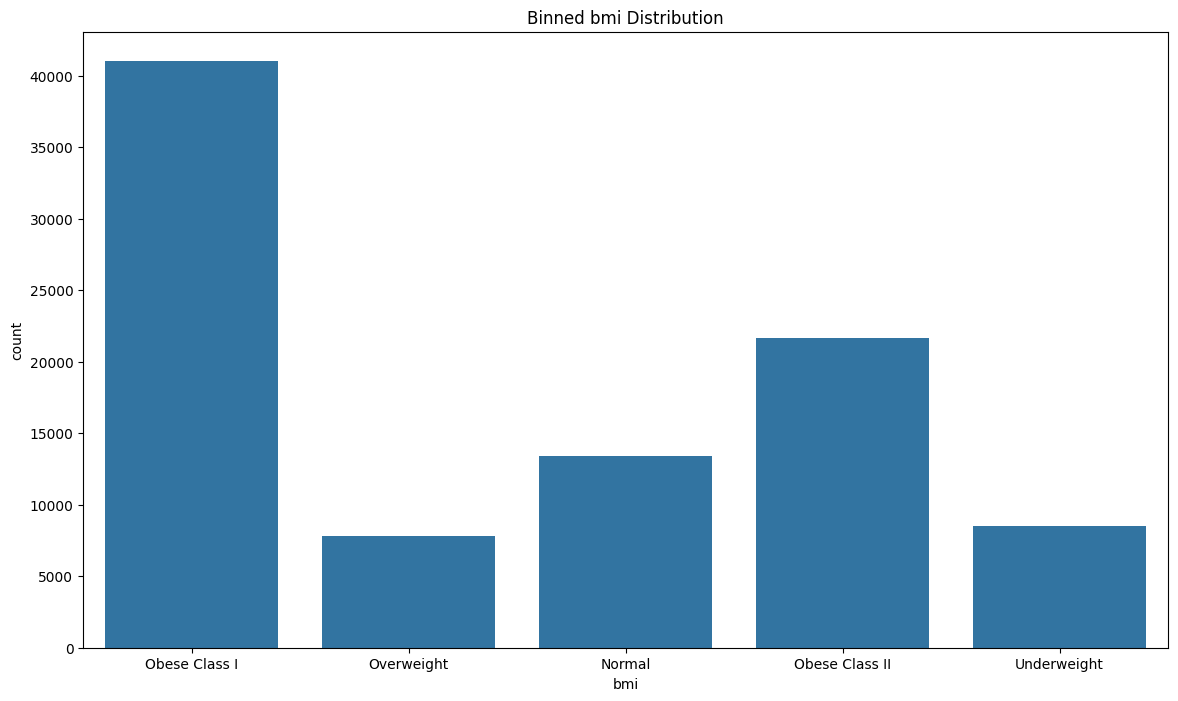

In [28]:
"""
Binning process:
bmi < 18.5 = Underweight
18.5 <= bmi < 22.9 = Normal
23 <= bmi < 24.9 = Overweight
25 <= bmi < 29.9 = Obese Class I
bmi => 30 = Obese Class II
"""
def bin_bmi(value):
	if 0 <= value < 18.5:
		return 'Underweight'
	elif 18.5 <= value < 22.9:
		return 'Normal'
	elif 23 <= value < 24.9:
		return 'Overweight'
	elif 25 <= value < 29.9:
		return 'Obese Class I'
	elif value >= 30:
		return 'Obese Class II'

df_preprocessed_binned['bmi'] = df_preprocessed_binned['bmi'].apply(bin_bmi)
print(f"bmi data values after binning: \n{df_preprocessed_binned['bmi'].value_counts()}\n")
# Check the data after binning
plt.figure(figsize=(14,8))
sns.countplot(data=df_preprocessed_binned, x='bmi')
plt.title("Binned bmi Distribution")
plt.show()


In [29]:
df_preprocessed_binned[df_preprocessed_binned['bmi'] == 'Unknown']

,gender,age,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [30]:
df_preprocessed_binned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93597 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               93597 non-null  object 
 1   age                  93597 non-null  float64
 2   smoking_history      93597 non-null  object 
 3   bmi                  92389 non-null  object 
 4   HbA1c_level          93597 non-null  float64
 5   blood_glucose_level  93597 non-null  float64
 6   diabetes             93597 non-null  int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 5.7+ MB


In [31]:
# Change 'category' data type to object
df_preprocessed_binned['bmi'] = df_preprocessed_binned['bmi'].astype('object')
df_preprocessed_binned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93597 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               93597 non-null  object 
 1   age                  93597 non-null  float64
 2   smoking_history      93597 non-null  object 
 3   bmi                  92389 non-null  object 
 4   HbA1c_level          93597 non-null  float64
 5   blood_glucose_level  93597 non-null  float64
 6   diabetes             93597 non-null  int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 5.7+ MB


#### 5. Encoding Categorical Columns

In [32]:
# Split categorical columns
df_preprocessed_encoded = df_preprocessed_binned.copy()
categorical_columns = df_preprocessed_encoded.select_dtypes(include='object')
categorical_columns

,gender,smoking_history,bmi
0,Female,No,Obese Class I
1,Female,Unknown,Obese Class I
2,Male,No,Obese Class I
3,Female,Yes,Overweight
4,Male,Yes,Normal
...,...,...,...
99994,Female,Unknown,Overweight
99996,Female,Unknown,Underweight
99997,Male,Yes,Obese Class I
99998,Female,No,Obese Class II


In [33]:
# Check unique value
for column in categorical_columns:
  print(f"{df_preprocessed_encoded[column].value_counts()}\n")

gender
Female    54598
Male      38981
Other        18
Name: count, dtype: int64

smoking_history
No         33388
Unknown    32390
Yes        27819
Name: count, dtype: int64

bmi
Obese Class I     41021
Obese Class II    21642
Normal            13415
Underweight        8480
Overweight         7831
Name: count, dtype: int64



In [34]:
# Replace 'Other' in 'gender' column
df_preprocessed_encoded['gender'] = df_preprocessed_encoded['gender'].replace({'Other': 'Female'})
df_preprocessed_encoded['gender'].value_counts()

gender
Female    54616
Male      38981
Name: count, dtype: int64

In [35]:
# Label encoding
for column in categorical_columns:
  if column == 'smoking_history':
    continue  # Skip 'smoking_history' for now, will be handled with OneHotEncoder
  else:
    le = LabelEncoder()
    df_preprocessed_encoded[column] = le.fit_transform(df_preprocessed_encoded[column])
df_preprocessed_encoded

,gender,age,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,No,1,6.6,4.941642,0
1,0,54.0,Unknown,1,6.6,4.382027,0
2,1,28.0,No,1,5.7,5.062595,0
3,0,36.0,Yes,3,5.0,5.043425,0
4,1,76.0,Yes,0,4.8,5.043425,0
...,...,...,...,...,...,...,...
99994,0,36.0,Unknown,3,4.8,4.976734,0
99996,0,2.0,Unknown,4,6.5,4.605170,0
99997,1,66.0,Yes,1,5.7,5.043425,0
99998,0,24.0,No,2,4.0,4.605170,0


In [36]:
# One Hot Encoding for 'smoking_history'
print(f"smoking_history unique values: {df_preprocessed_encoded['smoking_history'].unique()}")

smoking_history unique values: ['No' 'Unknown' 'Yes']


In [37]:
# Make sure 'smoking_history' is treated as categorical
df_preprocessed_encoded['smoking_history'] = pd.Categorical(
    df_preprocessed_encoded['smoking_history'],
    categories=['Yes', 'No', 'Unknown']
)

# Do one-hot encoding
smoke_encoded = pd.get_dummies(df_preprocessed_encoded['smoking_history'], prefix='smoke')
df_preprocessed_encoded = pd.concat([df_preprocessed_encoded, smoke_encoded], axis=1)

# Drop original 'smoking_history' column
df_preprocessed_encoded.drop(columns=['smoking_history'], axis=1, inplace=True)
# Check the result

df_preprocessed_encoded.head()

,gender,age,bmi,HbA1c_level,blood_glucose_level,diabetes,smoke_Yes,smoke_No,smoke_Unknown
0,0,80.0,1,6.6,4.941642,0,False,True,False
1,0,54.0,1,6.6,4.382027,0,False,False,True
2,1,28.0,1,5.7,5.062595,0,False,True,False
3,0,36.0,3,5.0,5.043425,0,True,False,False
4,1,76.0,0,4.8,5.043425,0,True,False,False


In [38]:
# Encode smoke columns
smoke_columns = ['smoke_Yes', 'smoke_No', 'smoke_Unknown']
for column in smoke_columns:
		df_preprocessed_encoded[column] = df_preprocessed_encoded[column].astype(int)
# Check 
df_preprocessed_encoded.head()

,gender,age,bmi,HbA1c_level,blood_glucose_level,diabetes,smoke_Yes,smoke_No,smoke_Unknown
0,0,80.0,1,6.6,4.941642,0,0,1,0
1,0,54.0,1,6.6,4.382027,0,0,0,1
2,1,28.0,1,5.7,5.062595,0,0,1,0
3,0,36.0,3,5.0,5.043425,0,1,0,0
4,1,76.0,0,4.8,5.043425,0,1,0,0


In [39]:
df_preprocessed_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93597 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               93597 non-null  int64  
 1   age                  93597 non-null  float64
 2   bmi                  93597 non-null  int64  
 3   HbA1c_level          93597 non-null  float64
 4   blood_glucose_level  93597 non-null  float64
 5   diabetes             93597 non-null  int64  
 6   smoke_Yes            93597 non-null  int64  
 7   smoke_No             93597 non-null  int64  
 8   smoke_Unknown        93597 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 7.1 MB


#### 4. Normalization

In [40]:
# Pick any column that has uniqe value > 2
df_preprocessed_normalized = df_preprocessed_encoded.copy()
numerical_column = []
for column in df_preprocessed_normalized.columns:
  if df_preprocessed_normalized[column].nunique() > 2:
    numerical_column.append(column)
numerical_column

['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [41]:
# MinMaxScaler
for column in numerical_column:
  scaler = MinMaxScaler()
  df_preprocessed_normalized[column] = scaler.fit_transform(df_preprocessed_normalized[[column]])
df_preprocessed_normalized

,gender,age,bmi,HbA1c_level,blood_glucose_level,diabetes,smoke_Yes,smoke_No,smoke_Unknown
0,0,1.000000,0.2,0.563636,0.474792,0,0,1,0
1,0,0.674675,0.2,0.563636,0.000000,0,0,0,1
2,1,0.349349,0.2,0.400000,0.577411,0,0,1,0
3,0,0.449449,0.6,0.272727,0.561147,0,1,0,0
4,1,0.949950,0.0,0.236364,0.561147,0,1,0,0
...,...,...,...,...,...,...,...,...,...
99994,0,0.449449,0.6,0.236364,0.504564,0,0,0,1
99996,0,0.024024,0.8,0.545455,0.189320,0,0,0,1
99997,1,0.824825,0.2,0.400000,0.561147,0,1,0,0
99998,0,0.299299,0.4,0.090909,0.189320,0,0,1,0


In [42]:
df_preprocessed_normalized.describe()

,gender,age,bmi,HbA1c_level,blood_glucose_level,diabetes,smoke_Yes,smoke_No,smoke_Unknown
count,93597.000000,93597.000000,93597.000000,93597.000000,93597.000000,93597.000000,93597.000000,93597.000000,93597.000000
mean,0.416477,0.517981,0.315732,0.365281,0.417286,0.072641,0.297221,0.356721,0.346058
std,0.492977,0.281797,0.236330,0.192239,0.238390,0.259548,0.457037,0.479034,0.475715
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.286787,0.200000,0.236364,0.189320,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.524525,0.200000,0.418182,0.474792,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.737237,0.400000,0.490909,0.582764,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


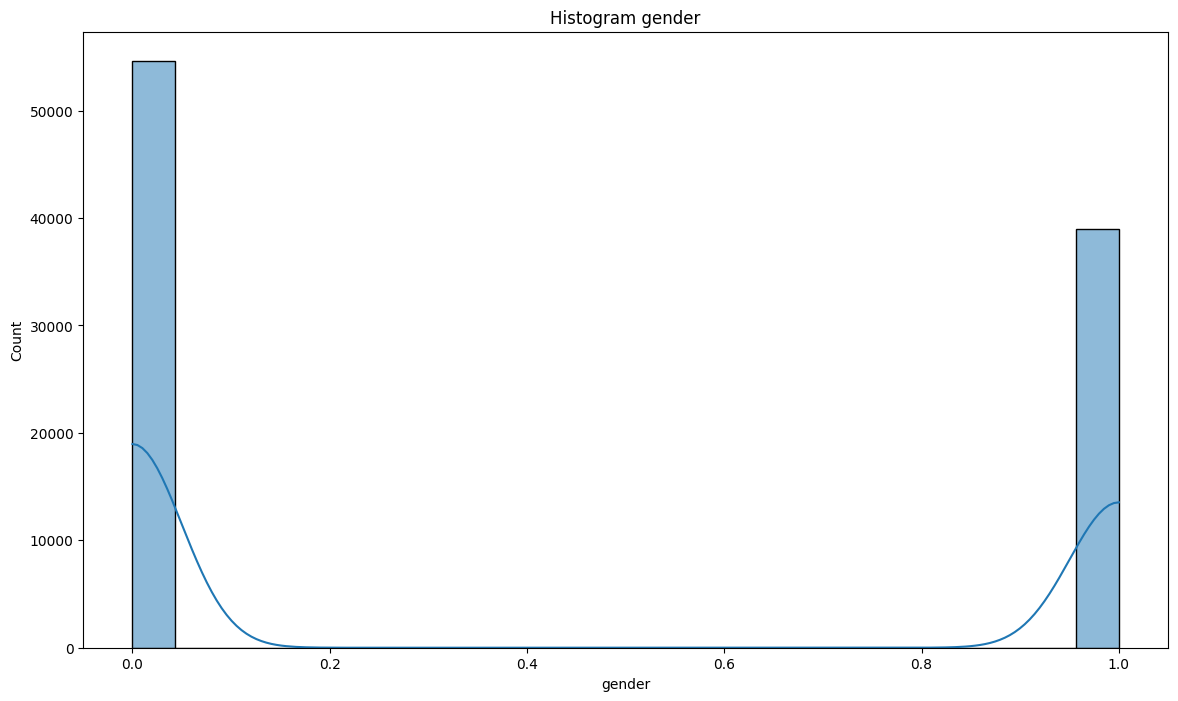

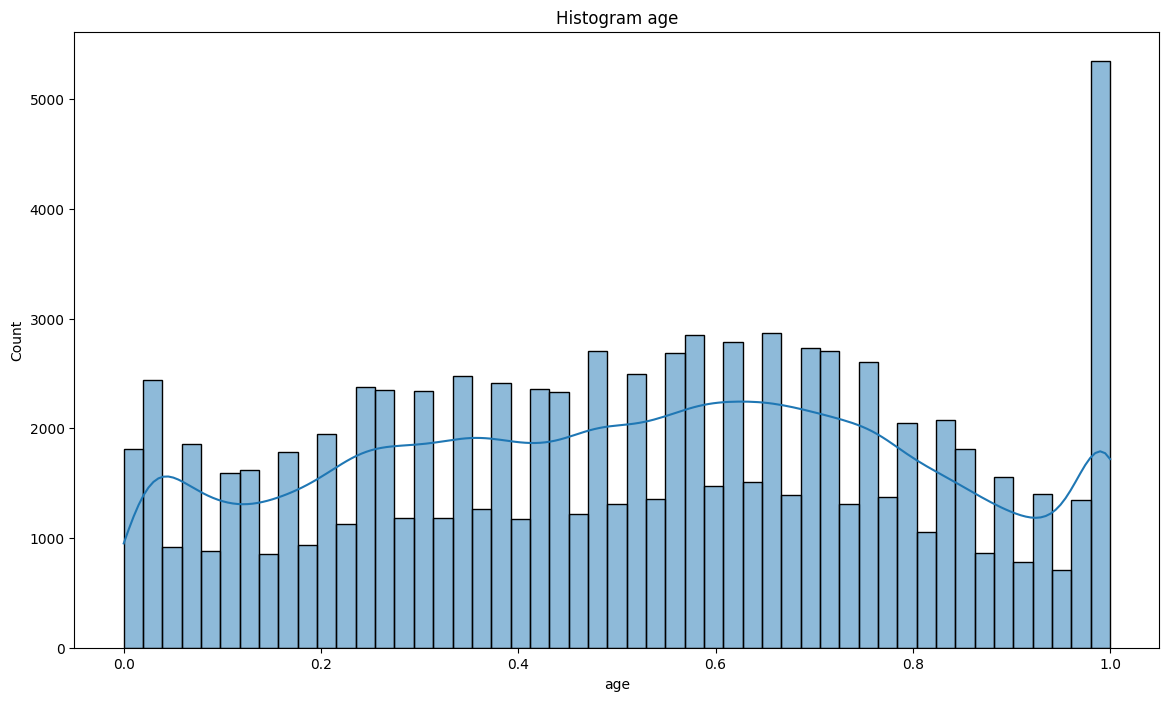

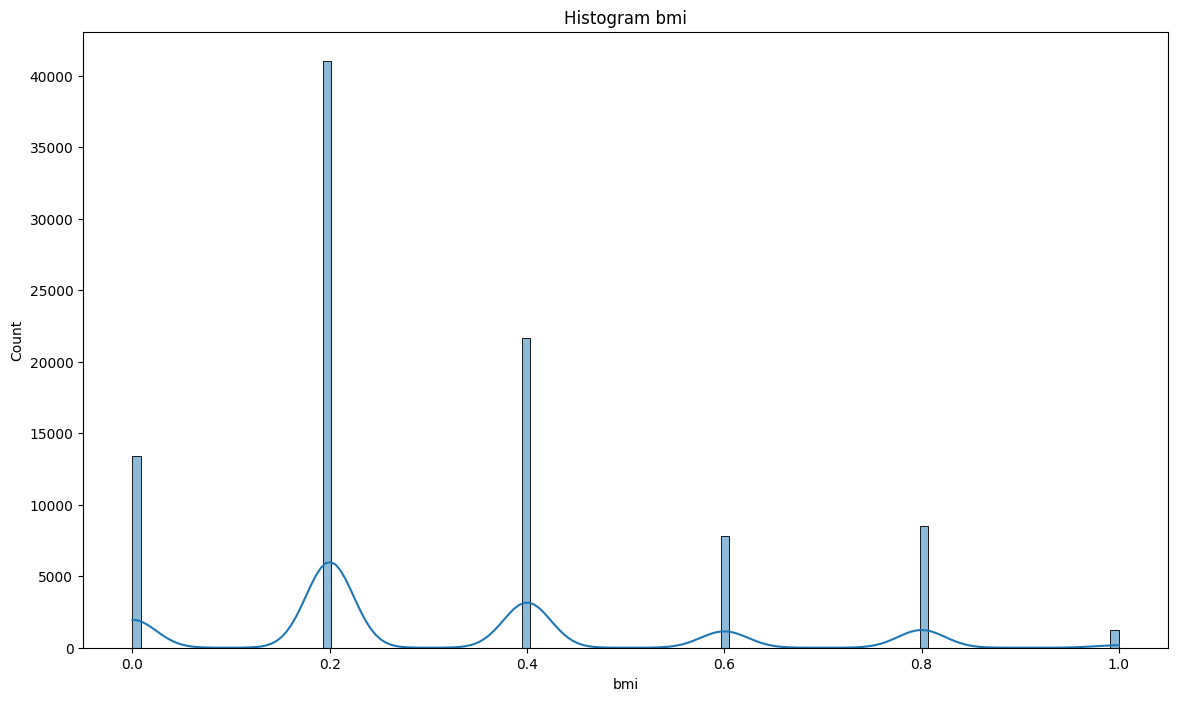

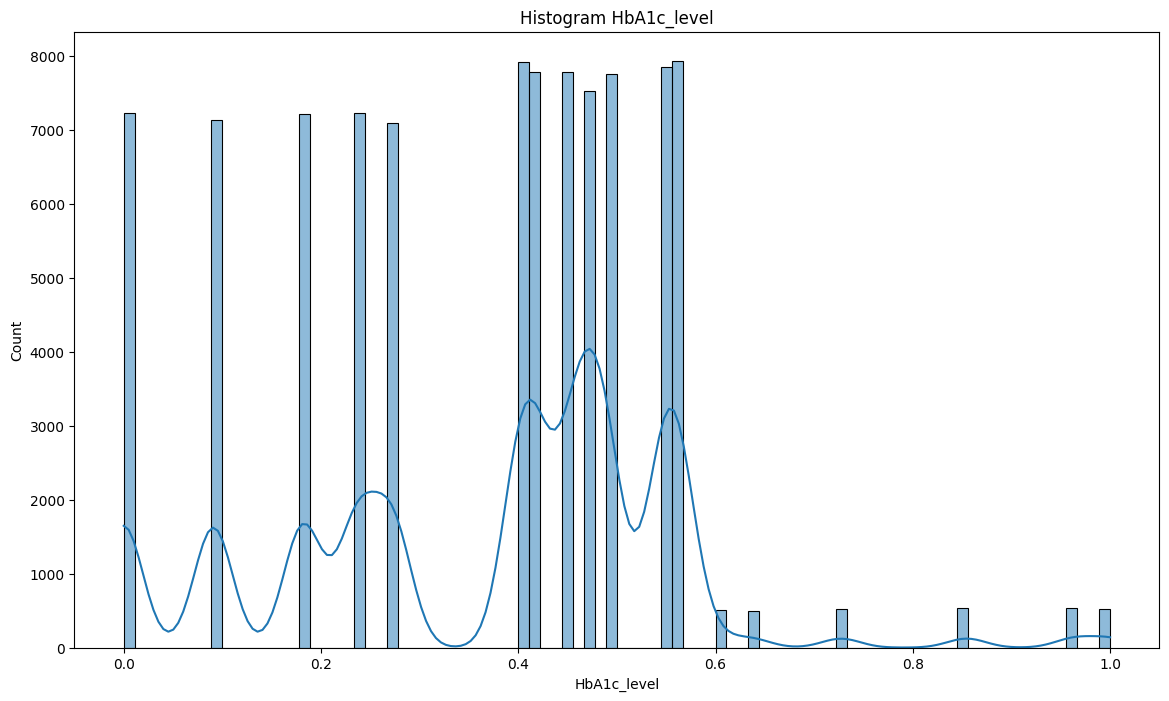

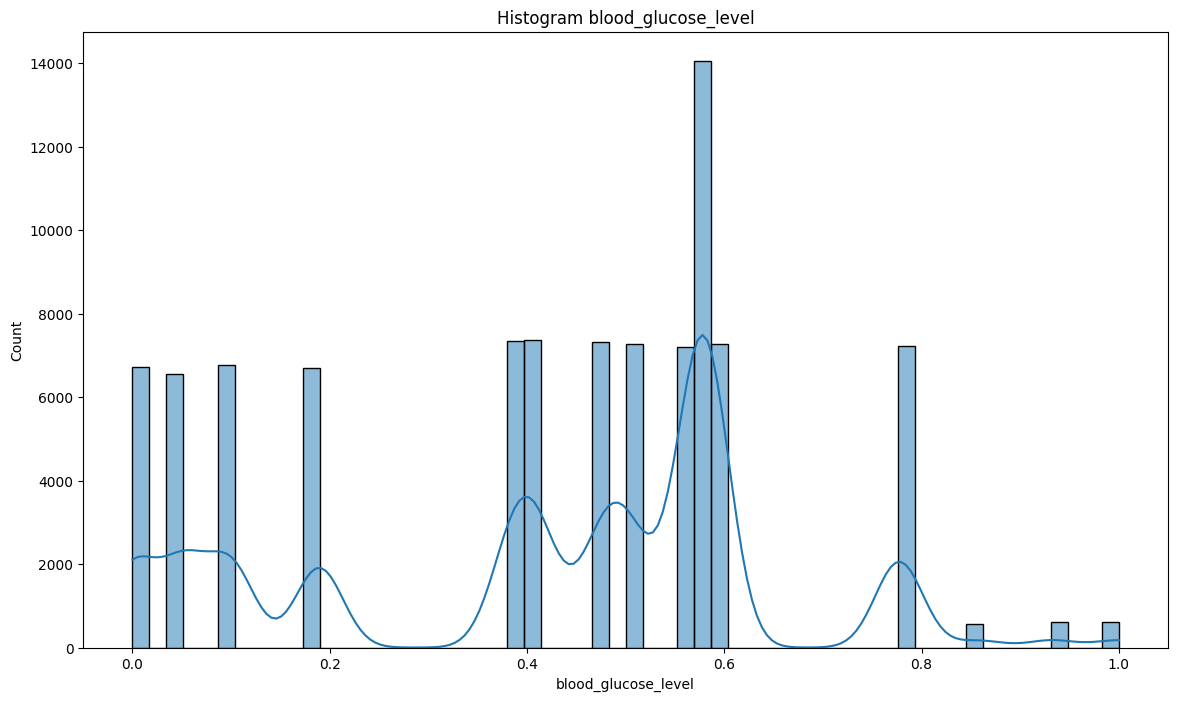

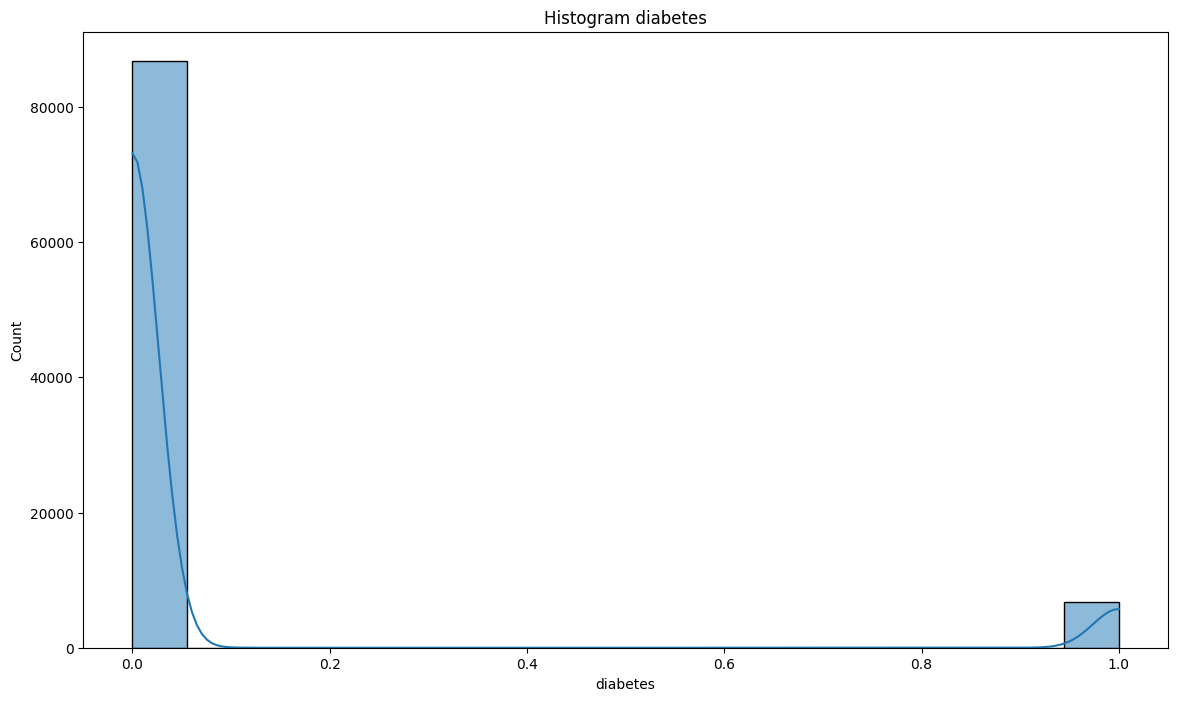

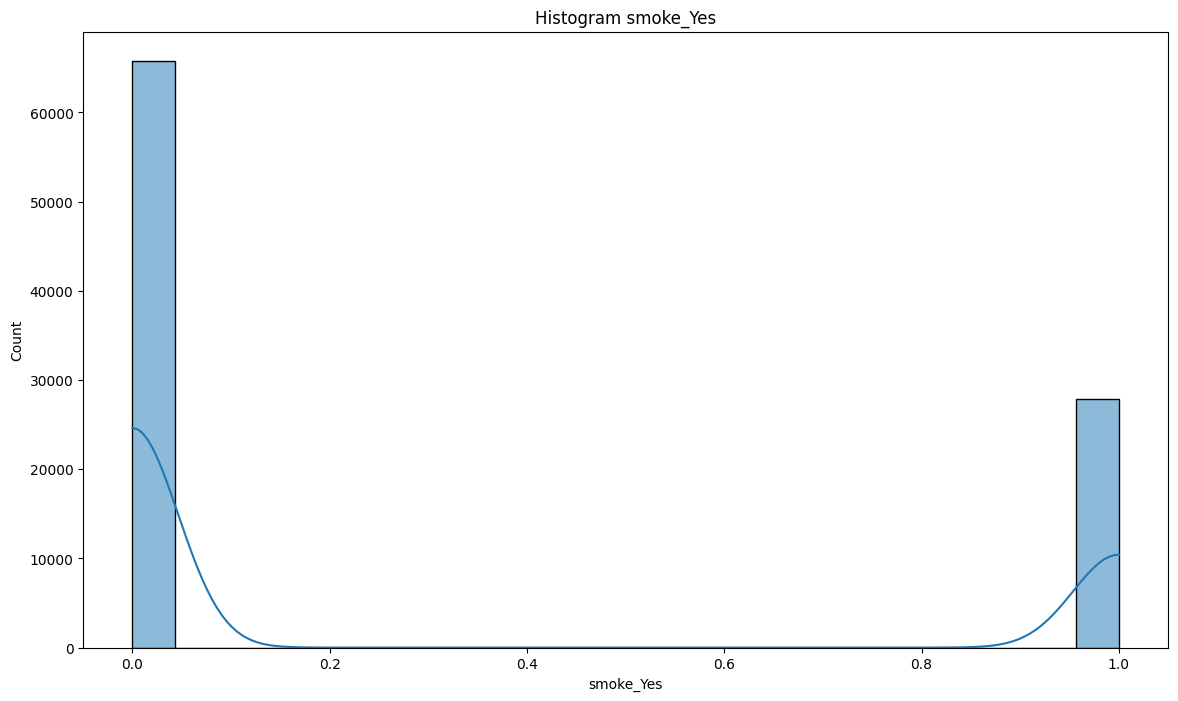

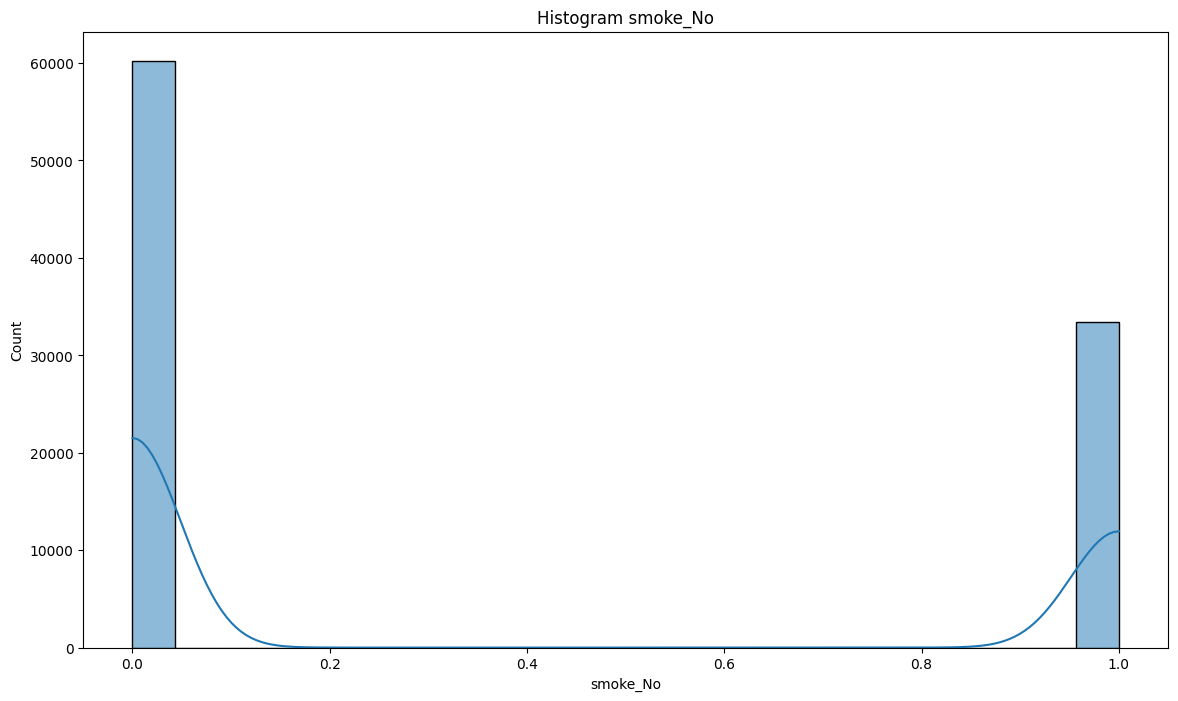

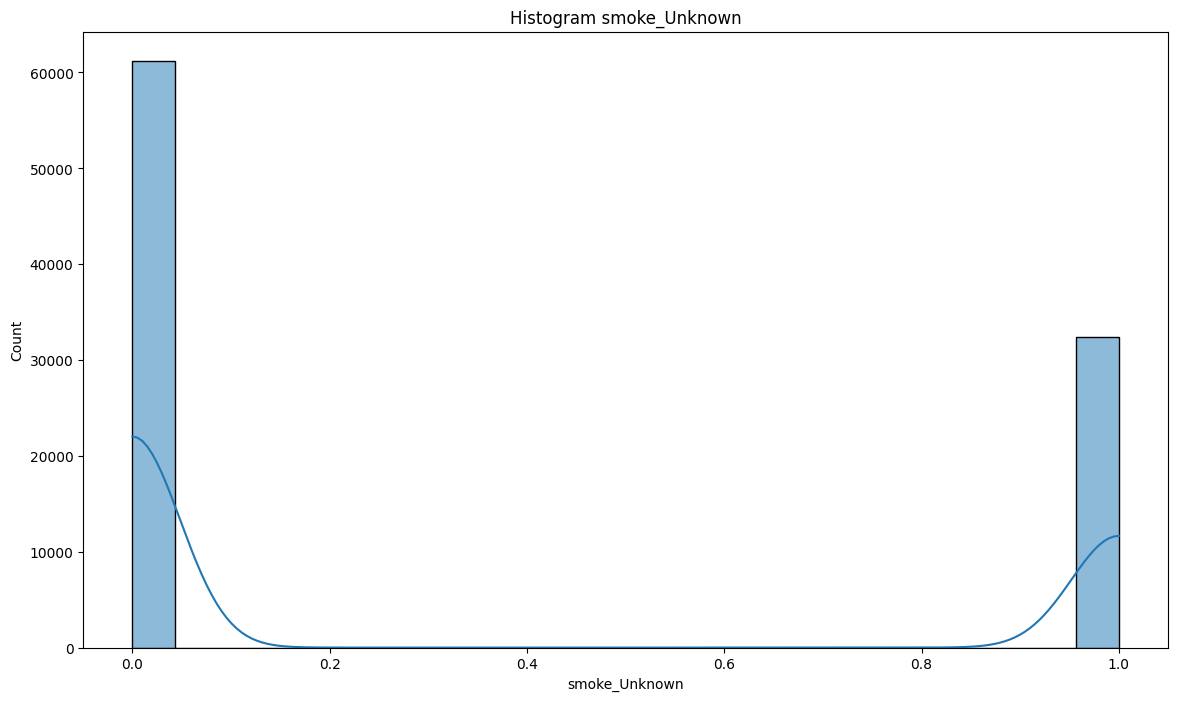

In [43]:
# Distribution of Numerical Columns
for column in df_preprocessed_normalized.columns:
	if df_preprocessed_normalized[column].dtype in ['float64', 'int64']:
		plt.figure(figsize=(14, 8))
		sns.histplot(data=df_preprocessed_normalized, x=column, kde=True)
		plt.title(f"Histogram {column}")
		plt.show()

## Modeling

### 1. Prepraration

In [44]:
# Split X and y
df_modeling = df_preprocessed_normalized.copy()
X = df_modeling.drop('diabetes', axis=1)
y = df_modeling['diabetes']

In [45]:
# Split to train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (74877, 8)
X_test shape: (18720, 8)
y_train shape: (74877,)
y_test shape: (18720,)


Because diabetes label is imbalance, we'll oversample it

In [46]:
# Oversample the train dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")

X_train_resampled shape: (138934, 8)
y_train_resampled shape: (138934,)


Text(0.5, 1.0, 'Label Distribution')

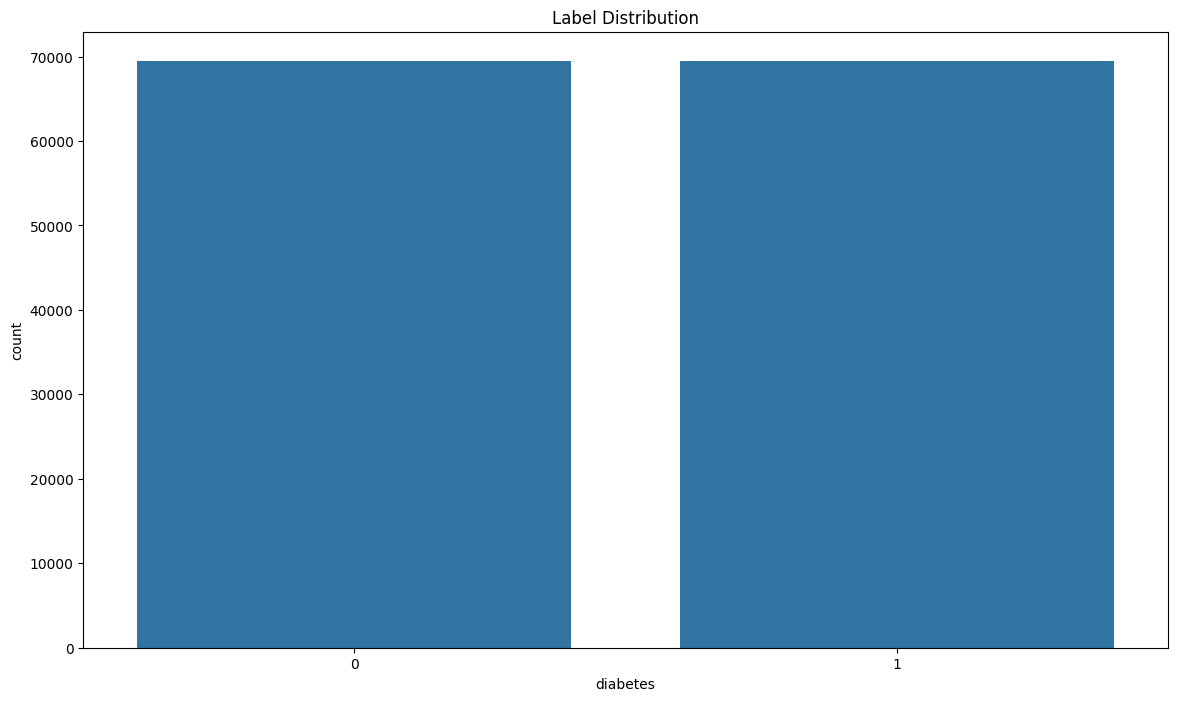

In [47]:
# Distribution check
plt.figure(figsize=(14, 8))
ax = sns.countplot(data=pd.DataFrame({'diabetes': y_train_resampled}), x='diabetes')
plt.title("Label Distribution")

### 2. Logistic Regression (LR)

In [48]:
model_lr = Sequential([
    Dense(1, activation='sigmoid', input_shape=(X_train_resampled.shape[1],))
])

model_lr.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])

# Callback
callback = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath='model/lr_best_model.h5', monitor='val_loss', save_best_only=True)
]

# Train the model
model_lr.fit(X_train_resampled, y_train_resampled, epochs=100, batch_size=32, validation_split=0.2, callbacks=callback)

Epoch 1/100


/home/valenttanda/capstone/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1749522488.269741    1577 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1749522488.270845    1577 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


3459/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7589 - loss: 0.5118

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7592 - loss: 0.5113 - val_accuracy: 0.8134 - val_loss: 0.3982
Epoch 2/100
3469/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8648 - loss: 0.3047

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8648 - loss: 0.3047 - val_accuracy: 0.8236 - val_loss: 0.3606
Epoch 3/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8638 - loss: 0.2862 - val_accuracy: 0.7969 - val_loss: 0.3889
Epoch 4/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8632 - loss: 0.2814 - val_accuracy: 0.7956 - val_loss: 0.3919
Epoch 5/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8643 - loss: 0.2787 - val_accuracy: 0.8060 - val_loss: 0.3750
Epoch 6/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8648 - loss: 0.2766 - val_accuracy: 0.8117 - val_loss: 0.3677
Epoch 7/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8646 - loss: 0.2768 - val_accuracy: 0.7877 - val_loss: 0.4038
Epoch 8/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8644 - loss: 0.2773 - val_accuracy: 0.7969 - val_loss: 0.3908
Epoch 9/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8665 - loss: 0.2755 - val

### 3. Artificial Neural Network (ANN)

In [49]:
model_ann = Sequential([
  Dense(128, activation='relu', input_shape=(X_train_resampled.shape[1],), kernel_regularizer=regularizers.l2(0.01)),
  Dense(64, activation='relu'),
  Dense(32, activation='relu'),
  Dense(1, activation='sigmoid')
])

model_ann.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])

# Callback
callback = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath='model/ann_best_model.h5', monitor='val_loss', save_best_only=True)
]

# Train model
model_ann.fit(X_train_resampled, y_train_resampled, epochs=100, batch_size=32, validation_split=0.2, callbacks=callback)

Epoch 1/100


/home/valenttanda/capstone/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3451/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3340

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8539 - loss: 0.3338 - val_accuracy: 0.8033 - val_loss: 0.4668
Epoch 2/100
3473/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8669 - loss: 0.2869

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8669 - loss: 0.2869 - val_accuracy: 0.7946 - val_loss: 0.4266
Epoch 3/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8725 - loss: 0.2696 - val_accuracy: 0.7266 - val_loss: 0.4368
Epoch 4/100
3463/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8795 - loss: 0.2539

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8795 - loss: 0.2539 - val_accuracy: 0.8363 - val_loss: 0.3531
Epoch 5/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8807 - loss: 0.2494 - val_accuracy: 0.8295 - val_loss: 0.3829
Epoch 6/100
3129/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8796 - loss: 0.2514

3459/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8796 - loss: 0.2514

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8796 - loss: 0.2514 - val_accuracy: 0.9552 - val_loss: 0.2274
Epoch 7/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8812 - loss: 0.2505 - val_accuracy: 0.9260 - val_loss: 0.2308
Epoch 8/100
3451/3474 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8809 - loss: 0.2508

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8809 - loss: 0.2508 - val_accuracy: 0.9424 - val_loss: 0.2163
Epoch 9/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8799 - loss: 0.2482 - val_accuracy: 0.8241 - val_loss: 0.3397
Epoch 10/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8802 - loss: 0.2488 - val_accuracy: 0.8894 - val_loss: 0.2898
Epoch 11/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8854 - loss: 0.2423 - val_accuracy: 0.8585 - val_loss: 0.3429
Epoch 12/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8785 - loss: 0.2505 - val_accuracy: 0.8600 - val_loss: 0.3195
Epoch 13/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8828 - loss: 0.2460 - val_accuracy: 0.8984 - val_loss: 0.2869
Epoch 14/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8833 - loss: 0.2452 - val_accuracy: 0.9140 - val_loss: 0.2380
Epoch 15/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8821 - loss: 0.246

## Evaluation

### Accuracy, Precision, Recall, F1-Score, Loss Metrics

In [50]:
loss_lr, acc_lr = model_lr.evaluate(X_test, y_test)
loss_ann, acc_ann = model_ann.evaluate(X_test, y_test)

# Recall
y_pred_lr = model_lr.predict(X_test)
y_pred_lr = np.where(y_pred_lr > 0.5, 1, 0)
recall_lr = recall_score(y_test, y_pred_lr)

y_pred_ann = model_ann.predict(X_test)
y_pred_ann = np.where(y_pred_ann > 0.5, 1, 0)
recall_ann = recall_score(y_test, y_pred_ann)

# Precision
precision_lr = precision_score(y_test, y_pred_lr)
precision_ann = precision_score(y_test, y_pred_ann)

# F1-score
f1_lr = f1_score(y_test, y_pred_lr)
f1_ann = f1_score(y_test, y_pred_ann)

evaluation = pd.DataFrame({
    'Model': ['LR', 'ANN'],
    'Loss': [loss_lr, loss_ann],
    'Accuracy': [acc_lr, acc_ann],
    'Recall': [recall_lr, recall_ann],
    'Precision': [precision_lr, precision_ann],
    'F1-score': [f1_lr, f1_ann]
})
evaluation

585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8878 - loss: 0.2559
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8356 - loss: 0.3188
135/585 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step

585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step


,Model,Loss,Accuracy,Recall,Precision,F1-score
0,LR,0.250982,0.890224,0.825774,0.387500,0.527478
1,ANN,0.311801,0.839423,0.943125,0.309181,0.465695


### Confusion Matrix

585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step


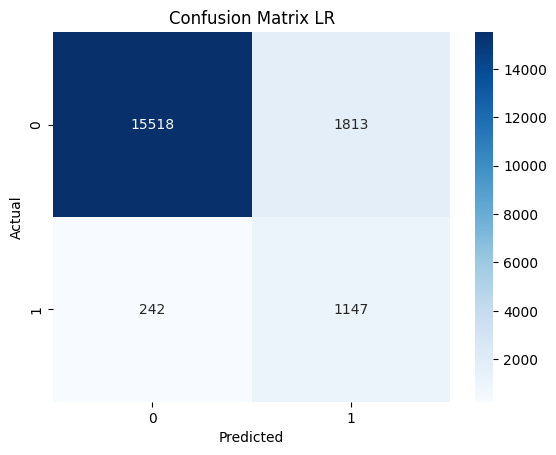

In [51]:
# Confusion matrix for LR
y_pred_lr = model_lr.predict(X_test)
y_pred_lr = np.where(y_pred_lr > 0.5, 1, 0)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr

# Plot confusion matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix LR')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


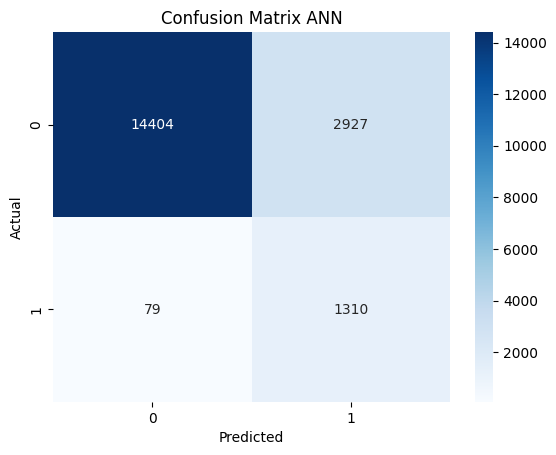

In [52]:
# Confusion matrix for ANN
y_pred_ann = model_ann.predict(X_test)
y_pred_ann = np.where(y_pred_ann > 0.5, 1, 0)
cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_ann

# Plot confusion matrix
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ROC Curve

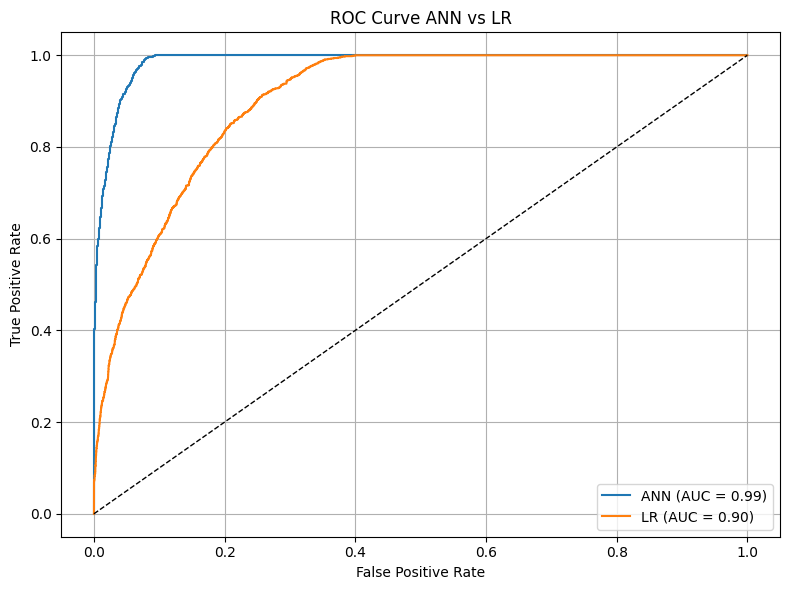

In [53]:
# Simulasi data probabilitas dan label aktual dari model ANN dan LR
np.random.seed(42)
y_true = np.concatenate([np.zeros(10000), np.ones(1000)])
y_scores_ann = np.random.beta(2, 5, size=11000) + (y_true * 0.5)
y_scores_lr = np.random.beta(2, 5, size=11000) + (y_true * 0.3)

# ROC Curve
fpr_ann, tpr_ann, thresholds_ann = roc_curve(y_true, y_scores_ann)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_true, y_scores_lr)

auc_ann = auc(fpr_ann, tpr_ann)
auc_lr = auc(fpr_lr, tpr_lr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {auc_ann:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve ANN vs LR')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Threshold Tuning

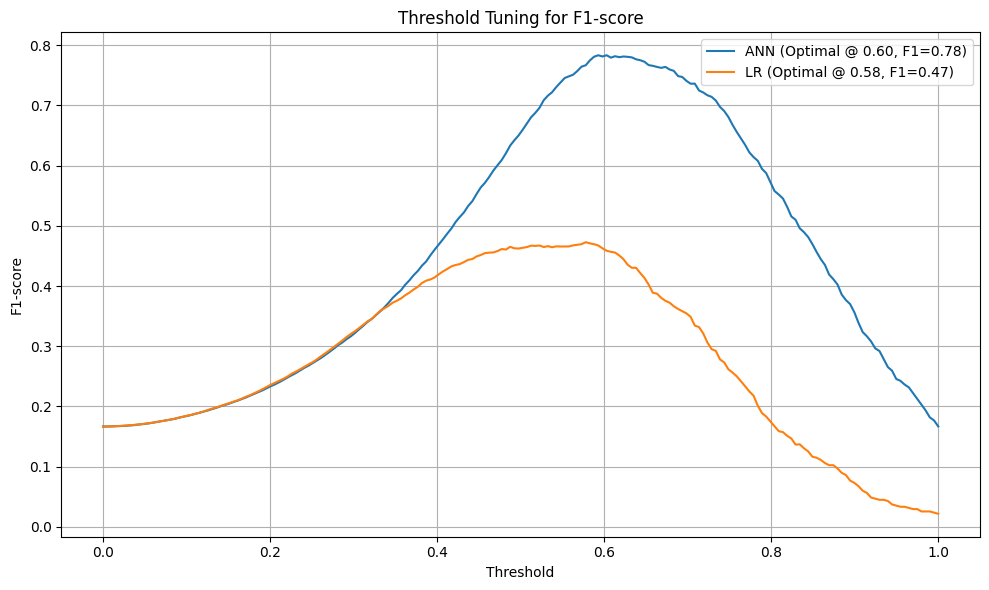

In [54]:
# Hitung F1-score untuk berbagai threshold
thresholds = np.linspace(0, 1, 200)
f1_scores_ann = [f1_score(y_true, y_scores_ann >= t) for t in thresholds]
f1_scores_lr = [f1_score(y_true, y_scores_lr >= t) for t in thresholds]

# Cari threshold optimal
optimal_threshold_ann = thresholds[np.argmax(f1_scores_ann)]
optimal_f1_ann = max(f1_scores_ann)

optimal_threshold_lr = thresholds[np.argmax(f1_scores_lr)]
optimal_f1_lr = max(f1_scores_lr)

# Plot F1-score vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_ann, label=f'ANN (Optimal @ {optimal_threshold_ann:.2f}, F1={optimal_f1_ann:.2f})')
plt.plot(thresholds, f1_scores_lr, label=f'LR (Optimal @ {optimal_threshold_lr:.2f}, F1={optimal_f1_lr:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('Threshold Tuning for F1-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Tuning (w/ Optuna)

### Logistic Regression Tuning

In [55]:

# Logistic Regression Model
def create_lr_model(trial):
  # Hyperparameter tuning for learning rate
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
  l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
  
  # Logistic regression model
  model = Sequential([
		Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(l2_reg))
	])
  
  model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
  
  # Train model
  history = model.fit(X_train_resampled, y_train_resampled,
											epochs=100, batch_size=32, validation_split=0.2,
											callbacks=[KerasPruningCallback(trial, 'val_loss')], verbose=0)
  
  # Accuracy
  val_acc = history.history['val_accuracy'][-1]
  return val_acc

In [56]:
# Run the study
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(create_lr_model, n_trials=25)

# Print the best hyperparameters
print("Best hyperparameters for Logistic Regression:")
print(study_lr.best_params)

[I 2025-06-10 09:32:44,013] A new study created in memory with name: no-name-f724d285-8472-4dfa-a671-2b12d45e9387
[I 2025-06-10 09:40:47,862] Trial 0 finished with value: 0.8026415109634399 and parameters: {'learning_rate': 0.0005570399346990799, 'l2_reg': 3.4032652839709296e-05}. Best is trial 0 with value: 0.8026415109634399.
[I 2025-06-10 09:47:28,391] Trial 1 finished with value: 0.777341902256012 and parameters: {'learning_rate': 2.2997699893729693e-05, 'l2_reg': 2.9084698100973447e-05}. Best is trial 0 with value: 0.8026415109634399.
[I 2025-06-10 09:54:02,012] Trial 2 finished with value: 0.8005902171134949 and parameters: {'learning_rate': 0.00014177752654776703, 'l2_reg': 0.0002058300973674803}. Best is trial 0 with value: 0.8026415109634399.
[I 2025-06-10 10:00:22,611] Trial 3 finished with value: 0.802101731300354 and parameters: {'learning_rate': 0.00021829874428956375, 'l2_reg': 0.00023629978443741382}. Best is trial 0 with value: 0.8026415109634399.
[I 2025-06-10 10:06:27

Best hyperparameters for Logistic Regression:
{'learning_rate': 0.00020743927570048557, 'l2_reg': 1.0101579606120928e-05}


### Artificial Neural Network Tuning

In [57]:
def create_ann_model(trial):
  n_layers = trial.suggest_int('n_layers', 1, 3)
  activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
  dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
  units = trial.suggest_int('units', 32, 64, step=32)

  # Bangun model ANN
  model = Sequential()
  model.add(InputLayer(shape=(X_train_resampled.shape[1],)))

  for _ in range(n_layers):
    model.add(Dense(units, activation=activation))
    model.add(Dropout(dropout_rate))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer=Adam(learning_rate=learning_rate),
                loss='binary_crossentropy',
                metrics=['accuracy'])

  # Tuning dengan pruning (optional)
  callback = KerasPruningCallback(trial, 'val_accuracy')

  history = model.fit(X_train_resampled, y_train_resampled,
                      epochs=100,
                      batch_size=32, 
                      validation_split=0.2,
                    	verbose=0,
                      callbacks=[callback])

  val_acc = history.history['val_accuracy'][-1]
  return val_acc

In [58]:
# Run the study
study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(create_ann_model, n_trials=25)
# Print the best hyperparameters
print("Best hyperparameters for ANN:")
print(study_ann.best_params)

[I 2025-06-10 10:38:19,113] A new study created in memory with name: no-name-fb9ef24f-4428-4094-8766-c4cc2b9102dd
[I 2025-06-10 10:46:21,382] Trial 0 finished with value: 0.8072479963302612 and parameters: {'n_layers': 3, 'activation': 'tanh', 'dropout_rate': 0.271707787820014, 'learning_rate': 5.0945537198742075e-05, 'units': 64}. Best is trial 0 with value: 0.8072479963302612.
[I 2025-06-10 10:52:58,248] Trial 1 finished with value: 0.8507935404777527 and parameters: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.07704979106203186, 'learning_rate': 6.796558029845423e-05, 'units': 64}. Best is trial 1 with value: 0.8507935404777527.
[I 2025-06-10 11:01:10,988] Trial 2 finished with value: 0.9019685387611389 and parameters: {'n_layers': 3, 'activation': 'relu', 'dropout_rate': 0.023936752529771343, 'learning_rate': 0.0030134533590626383, 'units': 64}. Best is trial 2 with value: 0.9019685387611389.
[I 2025-06-10 11:09:10,898] Trial 3 finished with value: 0.8290927410125732 and

Best hyperparameters for ANN:
{'n_layers': 3, 'activation': 'relu', 'dropout_rate': 0.023936752529771343, 'learning_rate': 0.0030134533590626383, 'units': 64}


## Retrain Model

### Logistic Regression

In [59]:
# Final model with best hyperparameters
def build_final_lr_model(learning_rate, l2_reg):
  model = Sequential([
		Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(l2_reg))
	])
  model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [60]:
best_lr_model = build_final_lr_model(learning_rate=study_lr.best_params['learning_rate'], l2_reg=study_lr.best_params['l2_reg'])
# Train the final model
history_lr = best_lr_model.fit(X_train_resampled, y_train_resampled, epochs=100, 
                               batch_size=32, validation_split=0.2, 
                               callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                               verbose=1)

Epoch 1/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6081 - loss: 0.6578 - val_accuracy: 0.4688 - val_loss: 0.7133
Epoch 2/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7886 - loss: 0.5559 - val_accuracy: 0.6134 - val_loss: 0.6658
Epoch 3/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8187 - loss: 0.5076 - val_accuracy: 0.6716 - val_loss: 0.6227
Epoch 4/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8308 - loss: 0.4732 - val_accuracy: 0.7068 - val_loss: 0.5850
Epoch 5/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8420 - loss: 0.4458 - val_accuracy: 0.7355 - val_loss: 0.5526
Epoch 6/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8458 - loss: 0.4254 - val_accuracy: 0.7498 - val_loss: 0.5292
Epoch 7/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8528 - loss: 0.4053 - val_accuracy: 0.7593 - val_loss: 0.5094
Epoch 8/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8529 - loss: 0

### Artificial Neural Network (ANN)

In [61]:
# Final model with best hyperparameters
def build_final_ann_model(learning_rate, n_layers, activation, dropout_rate, units):
	model = Sequential()
	model.add(InputLayer(shape=(X_train_resampled.shape[1],)))

	for _ in range(n_layers):
		model.add(Dense(units, activation=activation))
		model.add(Dropout(dropout_rate))

	model.add(Dense(1, activation='sigmoid'))

	model.compile(optimizer=Adam(learning_rate=learning_rate),
								loss='binary_crossentropy',
								metrics=['accuracy'])
	return model

In [62]:
best_ann_model = build_final_ann_model(learning_rate=study_ann.best_params['learning_rate'],
																				n_layers=study_ann.best_params['n_layers'],
																				activation=study_ann.best_params['activation'],
																				dropout_rate=study_ann.best_params['dropout_rate'],
																				units=study_ann.best_params['units'])
# Train the final model
history_ann = best_ann_model.fit(X_train_resampled, y_train_resampled, epochs=100, 
																	batch_size=32, validation_split=0.2, 
																	callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
																	verbose=1)

Epoch 1/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8549 - loss: 0.2966 - val_accuracy: 0.8962 - val_loss: 0.2619
Epoch 2/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8854 - loss: 0.2274 - val_accuracy: 0.8920 - val_loss: 0.3092
Epoch 3/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8889 - loss: 0.2176 - val_accuracy: 0.8455 - val_loss: 0.2992
Epoch 4/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8890 - loss: 0.2162 - val_accuracy: 0.8349 - val_loss: 0.3160
Epoch 5/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8899 - loss: 0.2120 - val_accuracy: 0.8423 - val_loss: 0.3294
Epoch 6/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8893 - loss: 0.2143 - val_accuracy: 0.8420 - val_loss: 0.3092
Epoch 7/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8923 - loss: 0.2106 - val_accuracy: 0.9023 - val_loss: 0.2453
Epoch 8/100
3474/3474 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8936 - loss: 0

### Evaluation

In [63]:
# Make classification report for LR
y_pred_prob_lr_final = best_lr_model.predict(X_test)
y_pred_lr_final = np.where(y_pred_prob_lr_final > 0.5, 1, 0).astype("int32")
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr_final))

# Make classification report for ANN
y_pred_prob_ann_final = best_ann_model.predict(X_test)
y_pred_ann_final = np.where(y_pred_prob_ann_final > 0.5, 1, 0).astype("int32")
print("Classification Report for ANN:")
print(classification_report(y_test, y_pred_ann_final))


585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     17331
           1       0.40      0.82      0.54      1389

    accuracy                           0.90     18720
   macro avg       0.69      0.86      0.74     18720
weighted avg       0.94      0.90      0.91     18720

585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step
Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17331
           1       0.38      0.90      0.53      1389

    accuracy                           0.88     18720
   macro avg       0.69      0.89      0.73     18720
weighted avg       0.95      0.88      0.90     18720



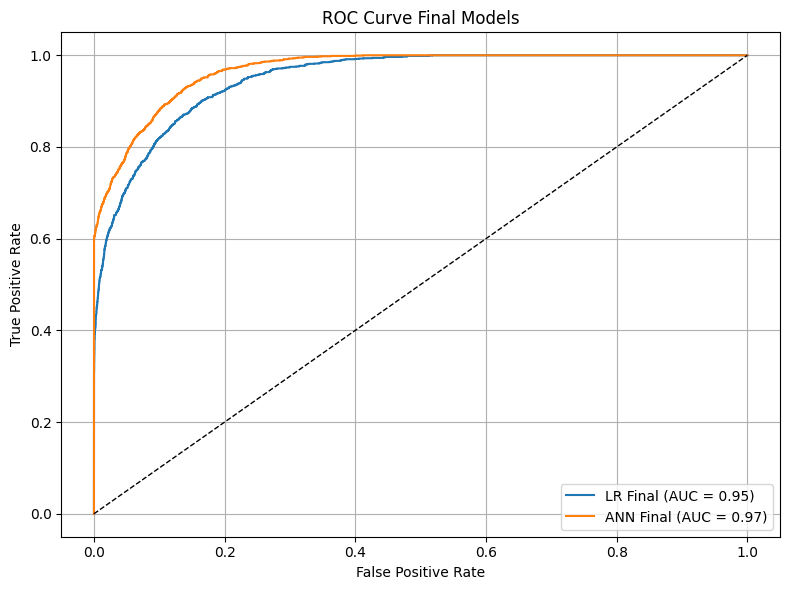

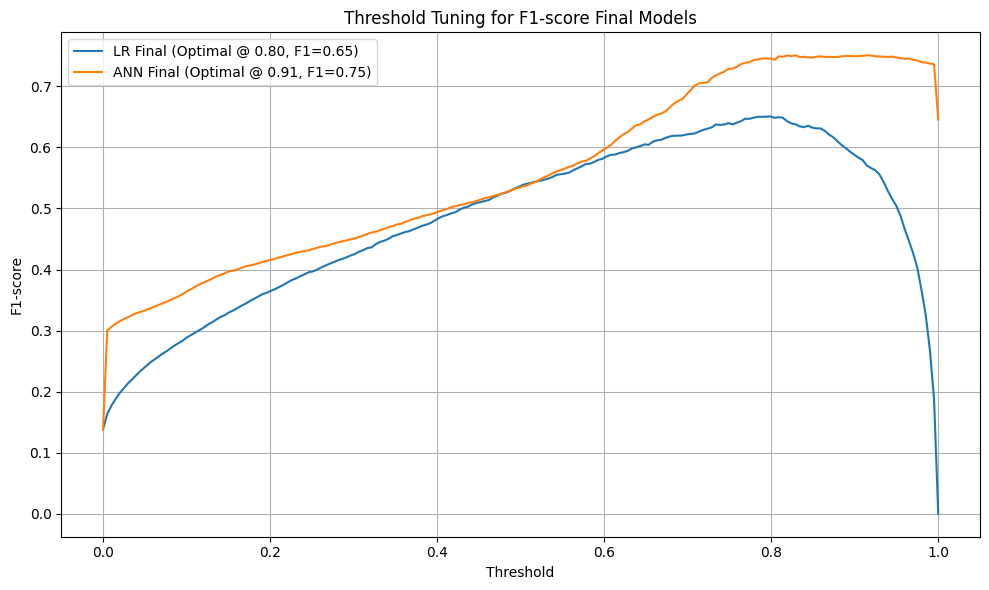

In [64]:
# ROC Curve for final models
fpr_lr_final, tpr_lr_final, _ = roc_curve(y_test, y_pred_prob_lr_final)
fpr_ann_final, tpr_ann_final, _ = roc_curve(y_test, y_pred_prob_ann_final)
auc_lr_final = auc(fpr_lr_final, tpr_lr_final)
auc_ann_final = auc(fpr_ann_final, tpr_ann_final)
# Plot ROC Curve for final models
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_final, tpr_lr_final, label=f'LR Final (AUC = {auc_lr_final:.2f})')
plt.plot(fpr_ann_final, tpr_ann_final, label=f'ANN Final (AUC = {auc_ann_final:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Final Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# F1-score vs Threshold for final models
thresholds_final = np.linspace(0, 1, 200)
f1_scores_lr_final = [f1_score(y_test, y_pred_prob_lr_final >= t) for t in thresholds_final]
f1_scores_ann_final = [f1_score(y_test, y_pred_prob_ann_final >= t) for t in thresholds_final]
# Optimal threshold for final models
optimal_threshold_lr_final = thresholds_final[np.argmax(f1_scores_lr_final)]
optimal_f1_lr_final = max(f1_scores_lr_final)
optimal_threshold_ann_final = thresholds_final[np.argmax(f1_scores_ann_final)]
optimal_f1_ann_final = max(f1_scores_ann_final)
# Plot F1-score vs Threshold for final models
plt.figure(figsize=(10, 6))
plt.plot(thresholds_final, f1_scores_lr_final, label=f'LR Final (Optimal @ {optimal_threshold_lr_final:.2f}, F1={optimal_f1_lr_final:.2f})')
plt.plot(thresholds_final, f1_scores_ann_final, label=f'ANN Final (Optimal @ {optimal_threshold_ann_final:.2f}, F1={optimal_f1_ann_final:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('Threshold Tuning for F1-score Final Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cross Validation

In [65]:
# Number of folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
results_lr = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
results_ann = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

fold_count = 1
for train_idx, val_idx in skf.split(X, y):
	X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
	y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

	# Oversample only on training fold
	smote = SMOTE(random_state=42)
	X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

	print(f"Fold {fold_count}/{n_splits}:\n")
	
	print(f"Training Logistic Regression Model...")
	# Logistic Regression Model
	model_lr_cv = build_final_lr_model(learning_rate=study_lr.best_params['learning_rate'], l2_reg=study_lr.best_params['l2_reg'])
	# Train the final model
	model_lr_cv.fit(X_train_res, y_train_res, epochs=100, 
                  batch_size=32, validation_split=0.2, 
                  callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                  verbose=0)
	print(f"Training process completed.")
 
	print(f"Evaluating Logistic Regression Model...")
	y_pred_lr = model_lr_cv.predict(X_val_fold)
	y_pred_lr = (y_pred_lr > 0.5).astype(int).flatten()
	results_lr['accuracy'].append(accuracy_score(y_val_fold, y_pred_lr))
	results_lr['precision'].append(precision_score(y_val_fold, y_pred_lr, zero_division=0))
	results_lr['recall'].append(recall_score(y_val_fold, y_pred_lr, zero_division=0))
	results_lr['f1'].append(f1_score(y_val_fold, y_pred_lr, zero_division=0))
	results_lr['roc_auc'] = roc_auc_score(y_val_fold, y_pred_lr)
	results_lr['confusion_matrix'] = confusion_matrix(y_val_fold, y_pred_lr)
	print("Evaluation completed.\n")
	time.sleep(1)
	print(f"Training ANN Model...")
	model_ann_cv = build_final_ann_model(learning_rate=study_ann.best_params['learning_rate'],
																				n_layers=study_ann.best_params['n_layers'],
																				activation=study_ann.best_params['activation'],
																				dropout_rate=study_ann.best_params['dropout_rate'],
																				units=study_ann.best_params['units'])
	# Train the final model
	model_ann_cv.fit(X_train_res, y_train_res, epochs=100, 
										batch_size=32, validation_split=0.2, 
										callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
										verbose=0)
	print(f"Training process completed.")
 
	print(f"Evaluating ANN Model...")
	y_pred_ann = model_ann_cv.predict(X_val_fold)
	y_pred_ann = (y_pred_ann > 0.5).astype(int).flatten()
	results_ann['accuracy'].append(accuracy_score(y_val_fold, y_pred_ann))
	results_ann['precision'].append(precision_score(y_val_fold, y_pred_ann, zero_division=0))
	results_ann['recall'].append(recall_score(y_val_fold, y_pred_ann, zero_division=0))
	results_ann['f1'].append(f1_score(y_val_fold, y_pred_ann, zero_division=0))
	results_ann['roc_auc'] = roc_auc_score(y_val_fold, y_pred_ann)
	results_ann['confusion_matrix'] = confusion_matrix(y_val_fold, y_pred_ann)
	print("Evaluation completed.\n")
	time.sleep(1)
	fold_count += 1

# Show average results
print("Logistic Regression CV Results:")
for metric in results_lr:
	print(f"{metric}: {np.mean(results_lr[metric]):.4f} ± {np.std(results_lr[metric]):.4f}")

print("\nANN CV Results:")
for metric in results_ann:
	print(f"{metric}: {np.mean(results_ann[metric]):.4f} ± {np.std(results_ann[metric]):.4f}")

Fold 1/5:

Training Logistic Regression Model...
Training process completed.
Evaluating Logistic Regression Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step
Evaluation completed.

Training ANN Model...
Training process completed.
Evaluating ANN Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step
Evaluation completed.

Fold 2/5:

Training Logistic Regression Model...
Training process completed.
Evaluating Logistic Regression Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step
Evaluation completed.

Training ANN Model...
Training process completed.
Evaluating ANN Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step
Evaluation completed.

Fold 3/5:

Training Logistic Regression Model...
Training process completed.
Evaluating Logistic Regression Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step
Evaluation completed.

Training ANN Model...
Training process completed.
Evaluating ANN Model...
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step
Evaluation completed.

Fold 4/5:

Training Logistic Re

## Saving Models

In [66]:
# Save the best models
best_lr_model.save('model/tuned_lr_model.h5')
best_ann_model.save('model/tuned_ann_model.h5')

In [67]:
# Pick the best model based on ROC AUC
if results_lr['roc_auc'] > results_ann['roc_auc']:
	best_model = best_lr_model
	print("Best model is Logistic Regression with ROC AUC:", results_lr['roc_auc'])
else:
	best_model = best_ann_model
	print("Best model is ANN with ROC AUC:", results_ann['roc_auc'])

Best model is ANN with ROC AUC: 0.8885301064374135


In [68]:
# Save the best model with SavedModel format
best_model.save('app/models/model.h5', save_format='tf')
print("Best model saved as 'app/models/model.h5'")

Best model saved as 'app/models/model.h5'
